<a href="https://colab.research.google.com/github/ERAEstudianteUB2026/UBPhD-Machine-Learning2026/blob/main/Taller_Clinica_ML_PCA_KMeans_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Clínica ML
# **Autor:Emiliano Rodríguez Arango**
- MySQL
- PCA  
- K-Means

Este notebook sigue el flujo del taller:

1. Conectarse a MySQL.
2. Ejecutar la consulta analítica.
3. Validar los datos descargados.
4. Guardar inmediatamente una copia local en **CSV** y **Pickle**.
5. Continuar trabajando desde la copia local aunque MySQL deje de estar disponible.
6. Realizar EDA.
7. Escalar las variables.
8. Aplicar PCA.
9. Analizar varianza explicada y loadings.
10. Seleccionar K con codo y silhouette.
11. Aplicar K-Means.
12. Perfilar e interpretar los clústeres.
13. Comparar resultados con y sin escalado.


## 1. Instalar librerías

In [ ]:
!pip -q install sqlalchemy pymysql scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00


## 2. Librerías

In [ ]:
import os
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

# Taller Clínica ML — PCA y K-Means




## 1. Conexión con la base de datos MySQL

In [ ]:
# PASO 1. IMPORTAR LIBRERÍAS Y CONECTAR CON MYSQL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, URL


# Datos del servidor
usuario   = "uokplago_doctorado2"
password  = "Doctorado2026%$"
host      = "cdtiueb.com.co"
puerto    = 3306
basedatos = "uokplago_clinica_ml"


#  Se Construye la  conexion
url = URL.create(
    drivername="mysql+pymysql",
    username=usuario,
    password=password,
    host=host,
    port=puerto,
    database=basedatos
)

engine = create_engine(url)

## 2. Identificación de las tablas de la base de datos

In [ ]:

# PASO 2. IDENTIFICAR LAS TABLAS DE LA BASE DE DATOS

query_tablas = """
SHOW TABLES;
"""

tablas = pd.read_sql(query_tablas, con=engine)

print("Número de tablas:", len(tablas))
tablas

Número de tablas: 4


,Tables_in_uokplago_clinica_ml
0,citas
1,medicos
2,pacientes
3,tratamientos


## 3. Muestra de las tablas


In [ ]:
# PASO 2. MUESTRA DE LAS TABLAS

medicos = pd.read_sql("SELECT * FROM medicos LIMIT 5", con=engine)
medicos

,id_medico,nombre,especialidad,anios_experiencia,salario_mensual,ciudad
0,1,Dr. Andrés Ramírez,Cardiología,15,8500000.0,Bogotá
1,2,Dra. Luisa Gómez,Pediatría,9,6200000.0,Medellín
2,3,Dr. Carlos Pérez,Dermatología,12,7100000.0,Cali
3,4,Dra. María Restrepo,Neurología,20,9800000.0,Bogotá
4,5,Dr. Juan Torres,Ortopedia,6,5400000.0,Barranquilla


In [ ]:
pacientes = pd.read_sql("SELECT * FROM pacientes LIMIT 5", con=engine)
pacientes

,id_paciente,nombre,edad,genero,peso_kg,altura_m,ciudad,fecha_registro
0,1,Ana María López,34,F,62.5,1.65,Bogotá,2023-01-15
1,2,Pedro Sánchez,45,M,82.0,1.78,Medellín,2023-02-10
2,3,Lucía Gómez,28,F,55.0,1.60,Cali,2023-03-05
3,4,Jorge Ramírez,52,M,90.5,1.75,Bogotá,2023-03-22
4,5,Camila Torres,19,F,50.0,1.58,Barranquilla,2023-04-01


In [ ]:
citas = pd.read_sql("SELECT * FROM citas LIMIT 5", con=engine)
citas

,id_cita,id_paciente,id_medico,fecha_cita,duracion_min,costo,diagnostico,satisfaccion,asistio
0,1,1,1,2024-01-05,45,250000.0,Hipertensión,5,1
1,2,2,5,2024-01-07,30,180000.0,Lumbalgia,4,1
2,3,3,3,2024-01-09,25,150000.0,Dermatitis,5,1
3,4,4,4,2024-01-11,60,320000.0,Migraña crónica,3,1
4,5,5,2,2024-01-13,20,120000.0,Vacunación,5,1


In [ ]:
tratamientos = pd.read_sql(
    "SELECT * FROM tratamientos LIMIT 5",
    con=engine
)

tratamientos

,id_tratamiento,id_cita,medicamento,dosis_mg,dias_tratamiento,costo_tratamiento
0,1,1,Losartán,50.0,30,80000.0
1,2,2,Ibuprofeno,400.0,10,25000.0
2,3,3,Hidrocortisona,20.0,15,45000.0
3,4,4,Sumatriptán,50.0,20,120000.0
4,5,5,Vacuna Triple,0.5,1,60000.0


## 4. Consulta del taller

In [ ]:
# Consulta SQL
query = """
SELECT
    m.especialidad AS especialidad,
    p.edad AS edad,
    c.duracion_min AS duracion_min,
    c.costo AS costo_cita,
    t.dosis_mg AS dosis_mg,
    t.dias_tratamiento AS dias_tratamiento,
    c.satisfaccion AS satisfaccion
FROM citas c
JOIN pacientes p
    ON p.id_paciente = c.id_paciente
JOIN medicos m
    ON m.id_medico = c.id_medico
JOIN tratamientos t
    ON t.id_cita = c.id_cita
ORDER BY c.id_cita
"""

In [ ]:
# Descargar datos
df = pd.read_sql(query, con=engine)

print("Datos descargados correctamente")
print("Dimensiones:", df.shape)
df.head(10)

Datos descargados correctamente
Dimensiones: (200, 7)


,especialidad,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,Cardiología,34,45,250000.0,50.0,30,5
1,Ortopedia,45,30,180000.0,400.0,10,4
2,Dermatología,28,25,150000.0,20.0,15,5
3,Neurología,52,60,320000.0,50.0,20,3
4,Pediatría,19,20,120000.0,0.5,1,5
5,Cardiología,61,50,260000.0,200.0,60,4
6,Ginecología,40,35,200000.0,5.0,90,5
7,Neurología,37,55,310000.0,500.0,90,3
8,Pediatría,25,25,130000.0,500.0,5,5
9,Dermatología,48,40,220000.0,10.0,60,4


## 5. Análisis exploratorio de datos (EDA)









### 5.1. Estadísticas descriptivas

In [ ]:
# PASO 4. ESTADÍSTICAS DESCRIPTIVAS
def descriptivas(df):

    variables_numericas = df.select_dtypes(include=np.number).columns

    resultados = []

    for variable in variables_numericas:

        resultados.append({
            "Variable": variable,
            "Media": df[variable].mean(),
            "Mediana": df[variable].median(),
            "Desv. estándar": df[variable].std(),
            "Mínimo": df[variable].min(),
            "Máximo": df[variable].max()
        })

    return pd.DataFrame(resultados)

In [ ]:
descriptivas(df)

,Variable,Media,Mediana,Desv. estándar,Mínimo,Máximo
0,edad,39.0400,38.0,11.651489,19.0,61.0
1,duracion_min,38.7500,37.5,12.255139,20.0,60.0
2,costo_cita,227250.0000,210000.0,71121.224984,110000.0,350000.0
3,dosis_mg,180.0525,100.0,188.402404,0.5,600.0
4,dias_tratamiento,37.6650,30.0,30.992020,1.0,120.0
5,satisfaccion,4.0900,4.0,0.790585,3.0,5.0


### 5.2. Histogramas de las variables cuantitativas

In [ ]:

# FUNCIÓN: GRÁFICOS DE VARIABLES CUANTITATIVAs
def graf_var_cuanti(df):

    variables_numericas = df.select_dtypes(include=np.number).columns

    for variable in variables_numericas:

        plt.figure(figsize=(7, 4))

        plt.hist(
            df[variable].dropna(),
            bins=10,
            edgecolor="black"
        )

        plt.title(f"Distribución de {variable}")
        plt.xlabel(variable)
        plt.ylabel("Frecuencia")

        plt.show()

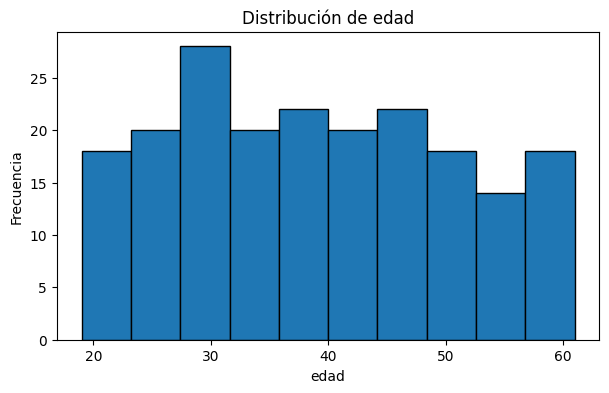

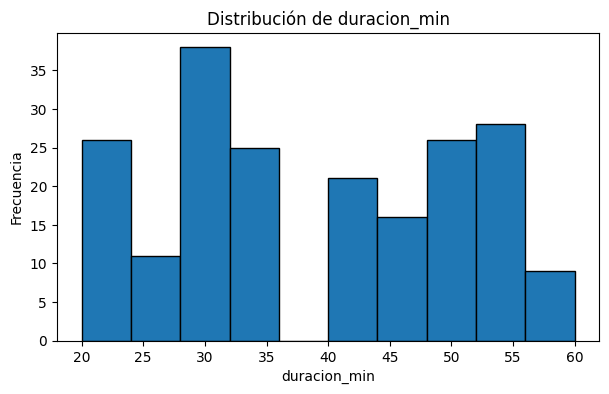

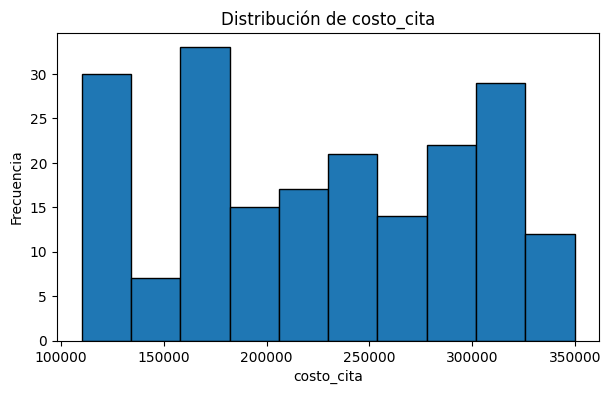

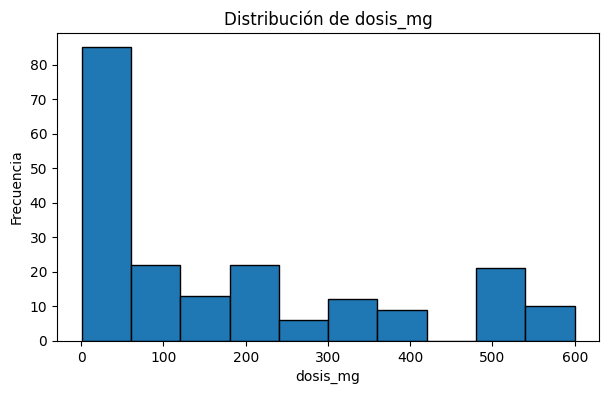

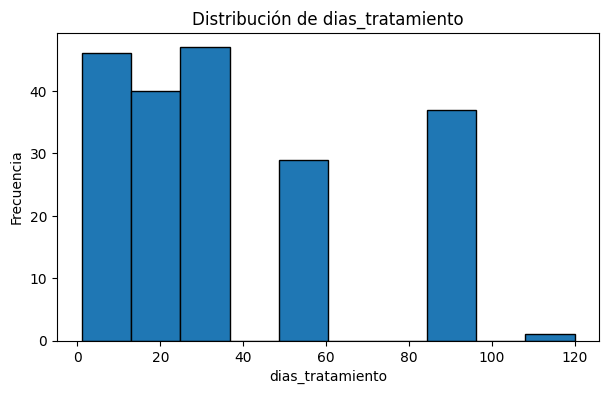

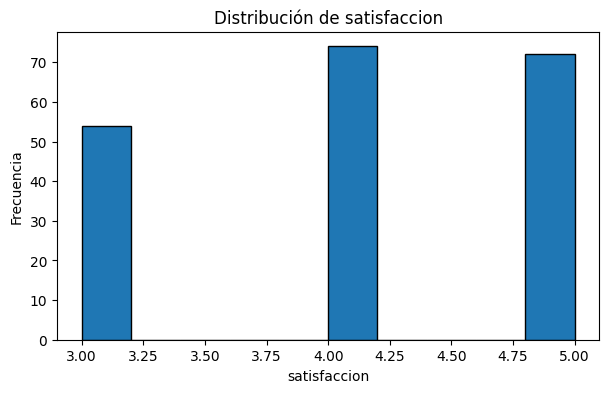

In [ ]:
graf_var_cuanti(df)


### 5.3. Matriz de correlación




In [ ]:
def matriz_corr(df):

    variables_numericas = df.select_dtypes(include=np.number)

    correlaciones = variables_numericas.corr()

    plt.figure(figsize=(9, 7))

    plt.imshow(
        correlaciones,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    plt.colorbar()

    plt.xticks(
        range(len(correlaciones.columns)),
        correlaciones.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlaciones.columns)),
        correlaciones.columns
    )

    # Valores de correlación dentro de la matriz
    for i in range(len(correlaciones.columns)):
        for j in range(len(correlaciones.columns)):
            plt.text(
                j,
                i,
                f"{correlaciones.iloc[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Matriz de correlación")
    plt.tight_layout()
    plt.show()

    return correlaciones

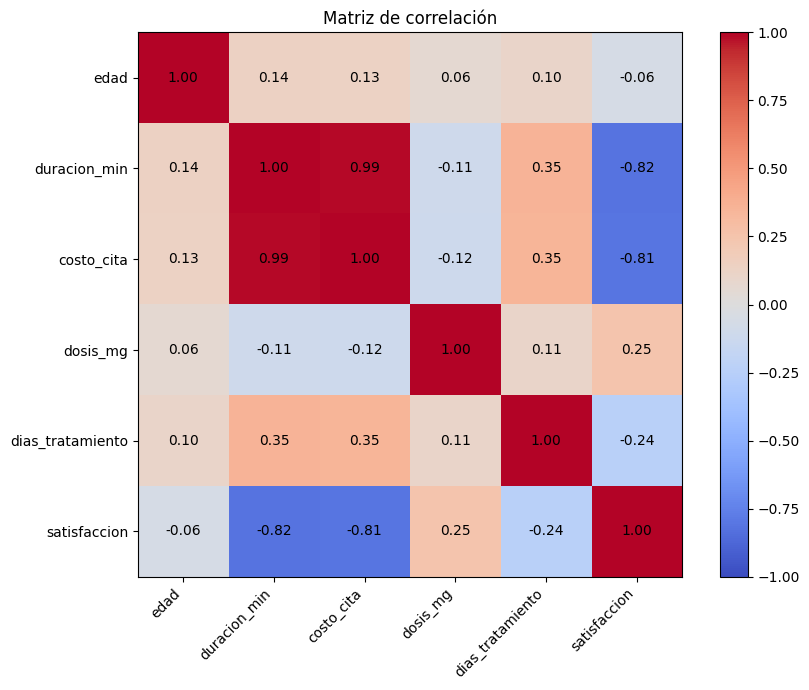

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
edad,1.000000,0.136546,0.131239,0.055866,0.104463,-0.060401
duracion_min,0.136546,1.000000,0.989126,-0.108683,0.352545,-0.818181
costo_cita,0.131239,0.989126,1.000000,-0.116714,0.349940,-0.811538
dosis_mg,0.055866,-0.108683,-0.116714,1.000000,0.105554,0.245222
dias_tratamiento,0.104463,0.352545,0.349940,0.105554,1.000000,-0.239951
satisfaccion,-0.060401,-0.818181,-0.811538,0.245222,-0.239951,1.000000


In [ ]:
matriz_corr(df)

### 5.4. Análisis de datos faltantes

In [ ]:
# Creamos una función para datos faltantes que nos diga cuantos hay y nos de una gráfica
def faltantes(df):

    # Contamos los datos faltantes
    faltantes = df.isnull().sum()

    # Calculamos el porcentaje de datos faltantes
    porcentaje_faltantes = (faltantes / len(df)) * 100
    porcentaje_faltantes = porcentaje_faltantes.round(2)

    # Creamos un DataFrame con los resultados
    resultados = pd.DataFrame({
        'Cantidad': faltantes,
        'Porcentaje': porcentaje_faltantes
    })
    resultados = resultados.sort_values(by='Porcentaje', ascending=False)

    # Mostramos los resultados
    print(resultados)


In [ ]:
faltantes(df)

                  Cantidad  Porcentaje
especialidad             0         0.0
edad                     0         0.0
duracion_min             0         0.0
costo_cita               0         0.0
dosis_mg                 0         0.0
dias_tratamiento         0         0.0
satisfaccion             0         0.0


## 6. Preparación de los datos

Para la preparaci´n de los datos vamos a hacer varias funciones:




#### Outliers

### 6.1. Detección y tratamiento de valores atípicos (outliers)

In [ ]:
# PASO 6.1. Decteccción de atípcos con rango intercuartil
variables_numericas = [ "edad","duracion_min","costo_cita","dosis_mg", "dias_tratamiento",
    "satisfaccion"]

def detectar_outliers_iqr(df, variables):

    resultados = []

    for variable in variables:

        Q1 = df[variable].quantile(0.25)
        Q3 = df[variable].quantile(0.75)

        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers = df[
            (df[variable] < limite_inferior) |
            (df[variable] > limite_superior)
        ]

        resultados.append({
            "Variable": variable,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Límite inferior": limite_inferior,
            "Límite superior": limite_superior,
            "Número de outliers": len(outliers)
        })

    return pd.DataFrame(resultados)

In [ ]:
tabla_outliers = detectar_outliers_iqr(df,variables_numericas)

tabla_outliers.round(2)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Número de outliers
0,edad,29.0,48.25,19.25,0.12,77.12,0
1,duracion_min,30.0,50.00,20.00,0.00,80.00,0
2,costo_cita,177500.0,300000.00,122500.00,-6250.00,483750.00,0
3,dosis_mg,20.0,325.00,305.00,-437.50,782.50,0
4,dias_tratamiento,15.0,60.00,45.00,-52.50,127.50,0
5,satisfaccion,3.0,5.00,2.00,0.00,8.00,0


- El método IQR no identificó valores atípicos en ninguna de las variables.

- No es  necesario eliminar ni modificar observaciones.

### 6.2. Escalado de las variables numéricas

In [ ]:
# Seleccionamos las variables numéricas
variables = [
    "edad",
    "duracion_min",
    "costo_cita",
    "dosis_mg",
    "dias_tratamiento",
    "satisfaccion"
]

X = df[variables].copy()

X.head()

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,34,45,250000.0,50.0,30,5
1,45,30,180000.0,400.0,10,4
2,28,25,150000.0,20.0,15,5
3,52,60,320000.0,50.0,20,3
4,19,20,120000.0,0.5,1,5


In [ ]:
# Escalamos los datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=variables,
    index=X.index
)

X_scaled.head()

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,-0.433648,0.511270,0.320679,-0.692023,-0.247942,1.153934
1,0.512806,-0.715778,-0.666026,1.170364,-0.894889,-0.114125
2,-0.949896,-1.124794,-1.088899,-0.851657,-0.733152,1.153934
3,1.115095,1.738318,1.307384,-0.692023,-0.571416,-1.382185
4,-1.724268,-1.533810,-1.511773,-0.955418,-1.186015,1.153934


In [ ]:
# Revisamos el escalado

X_scaled.describe().round(2)

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.72,-1.53,-1.65,-0.96,-1.19,-1.38
25%,-0.86,-0.72,-0.70,-0.85,-0.73,-1.38
50%,-0.09,-0.10,-0.24,-0.43,-0.25,-0.11
75%,0.79,0.92,1.03,0.77,0.72,1.15
max,1.89,1.74,1.73,2.23,2.66,1.15


- Las seis variables tienen media cercana a 0 y desviación estándar cercana a 1.

- Ahora están en escalas comparables, evitando que alguna domine PCA o K-Means por su magnitud.

## 7. Análisis de Componentes Principales (PCA)

### 7.1. Aplicación de PCA

In [ ]:
# Aplicamos PCA sobre los datos escalados

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Dimensión original:", X_scaled.shape)
print("Dimensión después de PCA:", X_pca.shape)

Dimensión original: (200, 6)
Dimensión después de PCA: (200, 6)


### 7.2. Varianza explicada por cada componente



In [ ]:
# Varianza explicada por cada componente

varianza = pca.explained_variance_ratio_

resultados = []

for i in range(len(varianza)):

    resultados.append({
        "Componente": f"PC{i + 1}",
        "Varianza explicada": varianza[i],
        "Porcentaje": varianza[i] * 100
    })

tabla_varianza = pd.DataFrame(resultados)

tabla_varianza.round(3)

,Componente,Varianza explicada,Porcentaje
0,PC1,0.492,49.236
1,PC2,0.195,19.491
2,PC3,0.154,15.444
3,PC4,0.120,12.035
4,PC5,0.036,3.616
5,PC6,0.002,0.179


- PC1 explica el 49.24 % de la varianza y PC2 el 19.49 %, siendo las componentes con mayor aporte.

- Las primeras componentes concentran gran parte de la información, mientras que PC5 y PC6 tienen una contribución pequeña.

### 7.3. Varianza explicada acumulada



In [ ]:
# Calculamos la varianza explicada acumulada

acumulada = []
suma = 0

for valor in varianza:
    suma = suma + valor
    acumulada.append(suma)

tabla_varianza["Varianza acumulada"] = acumulada

tabla_varianza.round(3)

,Componente,Varianza explicada,Porcentaje,Varianza acumulada
0,PC1,0.492,49.236,0.492
1,PC2,0.195,19.491,0.687
2,PC3,0.154,15.444,0.842
3,PC4,0.120,12.035,0.962
4,PC5,0.036,3.616,0.998
5,PC6,0.002,0.179,1.000


### 7.4. **Número de componentes que explican al menos el 80 % de la varianza**



In [ ]:
tabla_varianza["Varianza acumulada (%)"] = np.array(acumulada) * 100
# Mostramos las tres primeras componentes

tabla_varianza.head(3).round(3)

,Componente,Varianza explicada,Porcentaje,Varianza acumulada (%)
0,PC1,0.492,49.236,49.236
1,PC2,0.195,19.491,68.727
2,PC3,0.154,15.444,84.171


In [ ]:
# Buscamos cuántas componentes alcanzan al menos el 80 %

for i in range(len(acumulada)):

    if acumulada[i] >= 0.80:
        n_componentes = i + 1
        break

print("Número de componentes:", n_componentes)
print("Varianza acumulada:", round(acumulada[n_componentes - 1] * 100, 2), "%")

Número de componentes: 3
Varianza acumulada: 84.17 %


- Las dos primeras componentes acumulan el 68.73 % de la varianza.

- Al incluir PC3, la varianza acumulada alcanza el 84.17 %, superando el umbral del 80 %.

### 7.5. Loadings de los componentes principales



In [ ]:
# Calculamos los loadings de las componentes seleccionadas

componentes = ["PC1", "PC2", "PC3"]

loadings = pd.DataFrame(index=variables)

for componente, valores in zip(componentes, pca.components_[:3]):
    loadings[componente] = valores

loadings.round(3)

,PC1,PC2,PC3
edad,0.104,0.468,0.876
duracion_min,0.564,0.005,-0.040
costo_cita,0.563,-0.002,-0.041
dosis_mg,-0.113,0.719,-0.363
dias_tratamiento,0.266,0.479,-0.312
satisfaccion,-0.520,0.185,0.006


### 7.6. **Variables que dominan PC1 y PC2**

In [ ]:
# Ordenamos las variables por su importancia en PC1

pc1 = loadings["PC1"].abs().sort_values(ascending=False)
pc1

,PC1
duracion_min,0.564209
costo_cita,0.562920
satisfaccion,0.520046
dias_tratamiento,0.265925
dosis_mg,0.112914
edad,0.104290


In [ ]:
# Ordenamos las variables por su importancia en PC2

pc2 = loadings["PC2"].abs().sort_values(ascending=False)
pc2

,PC2
dosis_mg,0.719113
dias_tratamiento,0.478998
edad,0.468165
satisfaccion,0.185019
duracion_min,0.004645
costo_cita,0.002499


In [ ]:
# Ordenamos las variables por su importancia en PC3

pc3 = loadings["PC3"].abs().sort_values(ascending=False)
pc3

,PC3
edad,0.875717
dosis_mg,0.363451
dias_tratamiento,0.312482
costo_cita,0.041336
duracion_min,0.040382
satisfaccion,0.006188


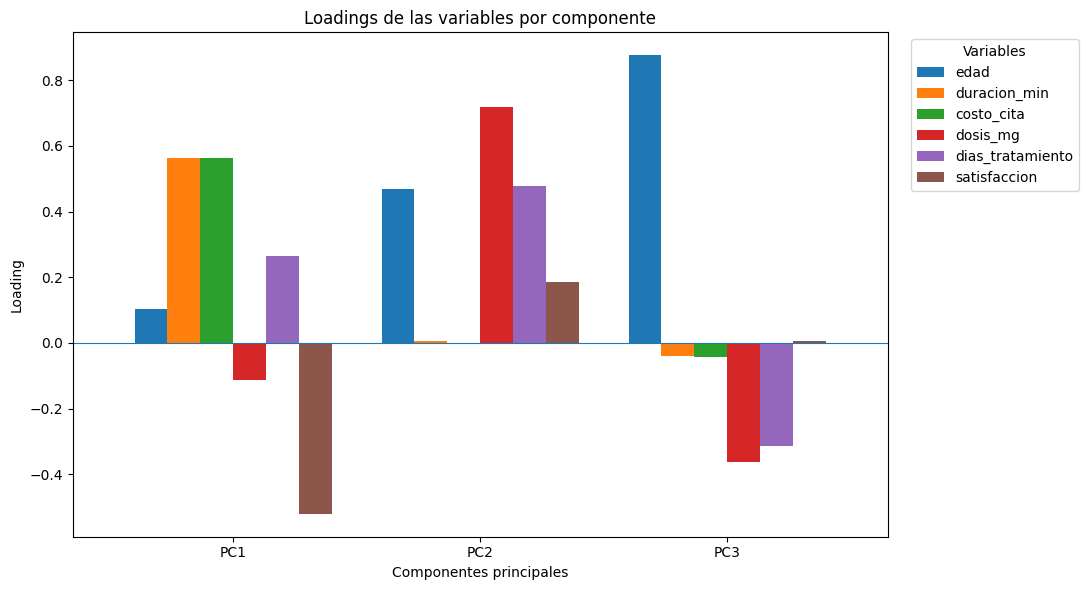

In [ ]:
# Graficamos los loadings de PC1 y PC2

# Graficamos los loadings agrupados por componente

loadings.T.plot(kind="bar",figsize=(11, 6),width=0.8)
plt.axhline(0, linewidth=0.8)
plt.xlabel("Componentes principales")
plt.ylabel("Loading")
plt.title("Loadings de las variables por componente")
plt.xticks(rotation=0)
plt.legend(title="Variables",bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.show()

- PC1 está dominada principalmente por duración, costo y satisfacción.

- PC2 está dominada por dosis, seguida por días de tratamiento y edad.

- PC3 está fuertemente asociada con la edad.

## 7.7. Construcción del PCA reducido

In [ ]:
# Construimos el PCA con las componentes seleccionadas

pca_reducido = PCA(n_components=n_componentes)

X_pca_reducido = pca_reducido.fit_transform(X_scaled)

print("Dimensión antes de PCA:", X_scaled.shape)
print("Dimensión después de PCA:", X_pca_reducido.shape)

Dimensión antes de PCA: (200, 6)
Dimensión después de PCA: (200, 3)


In [ ]:
# Guardamos las componentes en un DataFrame

pca_df = pd.DataFrame(X_pca_reducido, columns=["PC1", "PC2", "PC3"], index=X.index)

pca_df.head()

,PC1,PC2,PC3
0,-0.164140,-0.604352,-0.077520
1,-1.036060,0.630276,0.359069
2,-2.045545,-1.197327,-0.195635
3,2.478005,-0.500224,1.273790
4,-2.703830,-1.852240,-0.660544


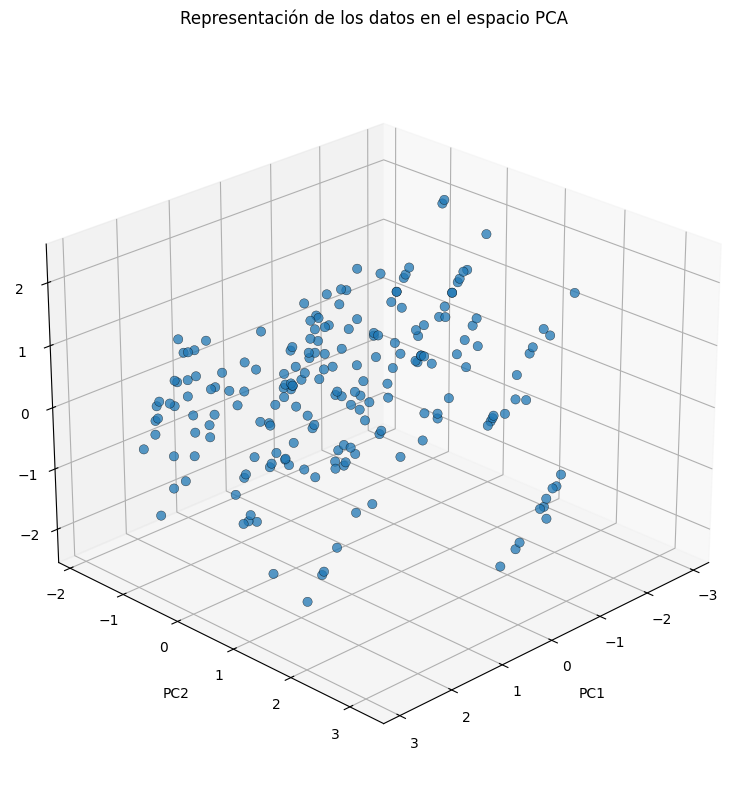

In [ ]:
# Visualizamos las tres componentes principales

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
           s=45, alpha=0.75, edgecolor="black", linewidth=0.3)

ax.set_xlabel("PC1", labelpad=10)
ax.set_ylabel("PC2", labelpad=10)
ax.set_zlabel("PC3", labelpad=10)

ax.set_title("Representación de los datos en el espacio PCA", pad=20)

ax.view_init(elev=25, azim=45)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

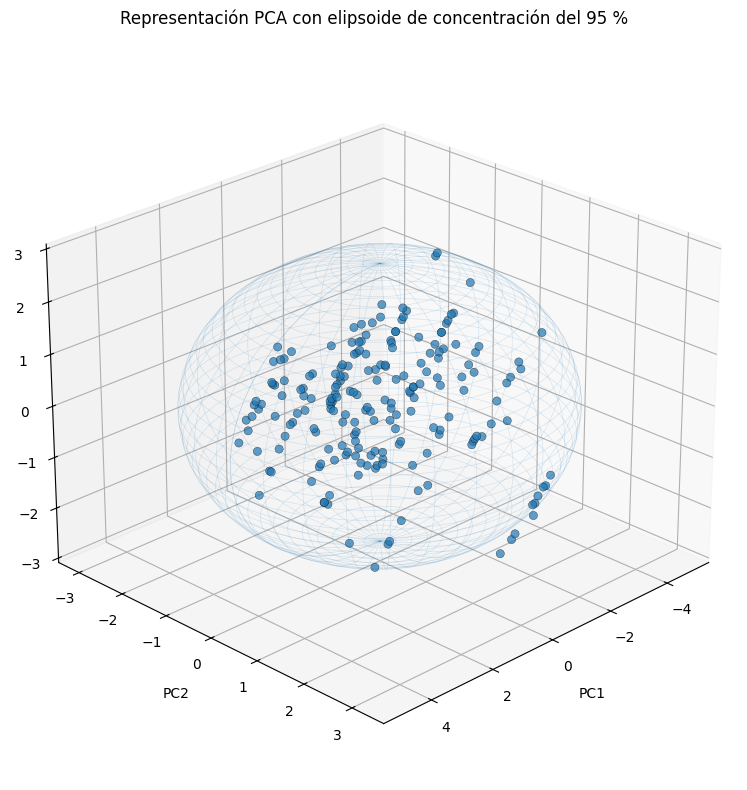

In [ ]:
# Visualizamos las tres componentes con un elipsoide del 95 %

from scipy.stats import chi2

centro = pca_df[["PC1", "PC2", "PC3"]].mean().values
desviaciones = pca_df[["PC1", "PC2", "PC3"]].std().values

nivel = np.sqrt(chi2.ppf(0.95, df=3))

u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 40)
u, v = np.meshgrid(u, v)

x = centro[0] + nivel * desviaciones[0] * np.cos(u) * np.sin(v)
y = centro[1] + nivel * desviaciones[1] * np.sin(u) * np.sin(v)
z = centro[2] + nivel * desviaciones[2] * np.cos(v)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
           s=35, alpha=0.7, edgecolor="black", linewidth=0.3)

ax.plot_wireframe(x, y, z, alpha=0.15, linewidth=0.5)

ax.set_xlabel("PC1", labelpad=10)
ax.set_ylabel("PC2", labelpad=10)
ax.set_zlabel("PC3", labelpad=10)
ax.set_title("Representación PCA con elipsoide de concentración del 95 %", pad=20)

ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

- La mayoría de las observaciones se concentran alrededor del centro del espacio formado por PC1, PC2 y PC3.

- El elipsoide del 95 % contiene la mayor parte de los datos, mostrando la región donde se concentra principalmente la información.

- Algunas observaciones aparecen cerca o fuera del límite del elipsoide, indicando casos menos habituales dentro de la estructura multivariada.

In [ ]:
# Gráfico 3D interactivo con elipsoide

import plotly.graph_objects as go
from scipy.stats import chi2

centro = pca_df[["PC1", "PC2", "PC3"]].mean().values
desviaciones = pca_df[["PC1", "PC2", "PC3"]].std().values

nivel = np.sqrt(chi2.ppf(0.95, df=3))

u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 40)
u, v = np.meshgrid(u, v)

x = centro[0] + nivel * desviaciones[0] * np.cos(u) * np.sin(v)
y = centro[1] + nivel * desviaciones[1] * np.sin(u) * np.sin(v)
z = centro[2] + nivel * desviaciones[2] * np.cos(v)

fig = go.Figure()

# Observaciones
fig.add_trace(go.Scatter3d(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    z=pca_df["PC3"],
    mode="markers",
    name="Observaciones",
    marker=dict(size=4, opacity=0.75)
))

# Elipsoide
fig.add_trace(go.Surface(
    x=x,
    y=y,
    z=z,
    opacity=0.15,
    showscale=False,
    name="Elipsoide 95 %"
))

fig.update_layout(
    title="Espacio PCA con elipsoide de concentración del 95 %",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=700
)

fig.show()

- PCA permitió reducir las 6 variables originales a 3 componentes principales.

- Las tres componentes conservan aproximadamente el 84.17 % de la varianza total de los datos.

## 8. K-Means




In [ ]:
# Datos que utilizaremos en K-Means
#  uasrmaos lso datos de pca

X_kmeans = pca_df.copy()

X_kmeans.head()

,PC1,PC2,PC3
0,-0.164140,-0.604352,-0.077520
1,-1.036060,0.630276,0.359069
2,-2.045545,-1.197327,-0.195635
3,2.478005,-0.500224,1.273790
4,-2.703830,-1.852240,-0.660544


### 8.1. Método del codo




In [ ]:
# Evaluamos diferentes valores de K

from sklearn.cluster import KMeans

valores_k = range(2, 11)
inercias = []

for k in valores_k:
    kmeans = KMeans(n_clusters=k, n_init=30, random_state=42)
    kmeans.fit(X_kmeans)
    inercias.append(kmeans.inertia_)

In [ ]:
# Guardamos los resultados

resultados_codo = pd.DataFrame({"K": valores_k, "Inercia": inercias})

resultados_codo.round(3)

,K,Inercia
0,2,584.175
1,3,463.727
2,4,366.990
3,5,288.864
4,6,241.168
5,7,207.160
6,8,181.587
7,9,166.456
8,10,147.881


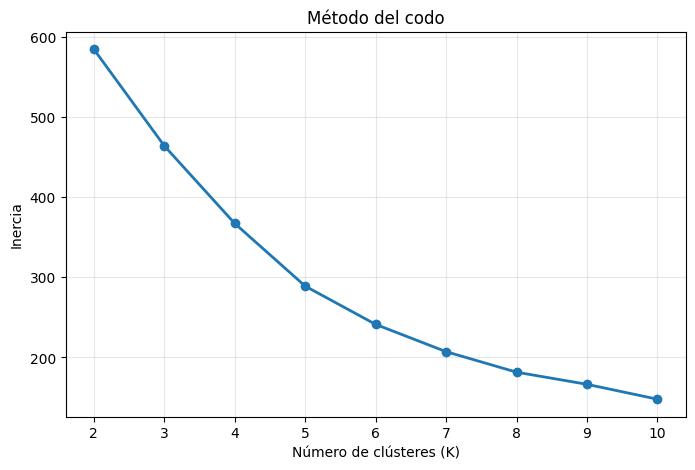

In [ ]:
# Graficamos el método del codo

plt.figure(figsize=(8, 5))

plt.plot(resultados_codo["K"], resultados_codo["Inercia"], marker="o", linewidth=2)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(valores_k)
plt.grid(alpha=0.3)

plt.show()

- La inercia disminuye rápidamente para los primeros valores de K y luego la reducción se hace progresivamente menor.

- El codo no es completamente definido, por lo que no es conveniente seleccionar K únicamente a partir de esta gráfica.

### 8.2. Selección del número óptimo de clústeres



In [ ]:
# Evaluamos la calidad de los clústeres

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

resultados = []

for k in valores_k:
    kmeans = KMeans(n_clusters=k, n_init=30, random_state=42)
    etiquetas = kmeans.fit_predict(X_kmeans)

    resultados.append({
        "K": k,
        "Silhouette": silhouette_score(X_kmeans, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(X_kmeans, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(X_kmeans, etiquetas)
    })

metricas_k = pd.DataFrame(resultados)

metricas_k.round(3)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.356,1.068,144.346
1,3,0.331,1.219,116.044
2,4,0.334,1.114,114.481
3,5,0.370,0.874,121.711
4,6,0.374,0.960,123.701
5,7,0.384,0.989,124.669
6,8,0.374,0.922,125.138
7,9,0.344,1.004,120.998
8,10,0.346,0.926,123.081


### Recordemos

- Silhouette: mide qué tan bien separadas están las observaciones entre los clústeres. Mayor es mejor.

- Davies-Bouldin: mide qué tan similares son los clústeres entre sí. Menor es mejor.

- Calinski-Harabasz: compara la separación entre clústeres con la dispersión dentro de ellos. Mayor es mejor.

### Interpretación

- Buscaremos un K con clústeres bien separados y compactos.

- No elegiremos K con una sola métrica; compararemos los tres criterios y su estabilidad.

In [ ]:
# Normalizamos las métricas para poder compararlas en una misma gráfica

metricas_grafica = metricas_k.copy()

metricas_grafica["Silhouette"] = (metricas_k["Silhouette"] - metricas_k["Silhouette"].min()) / (metricas_k["Silhouette"].max() - metricas_k["Silhouette"].min())

metricas_grafica["Davies-Bouldin"] = (metricas_k["Davies-Bouldin"].max() - metricas_k["Davies-Bouldin"]) / (metricas_k["Davies-Bouldin"].max() - metricas_k["Davies-Bouldin"].min())

metricas_grafica["Calinski-Harabasz"] = (metricas_k["Calinski-Harabasz"] - metricas_k["Calinski-Harabasz"].min()) / (metricas_k["Calinski-Harabasz"].max() - metricas_k["Calinski-Harabasz"].min())

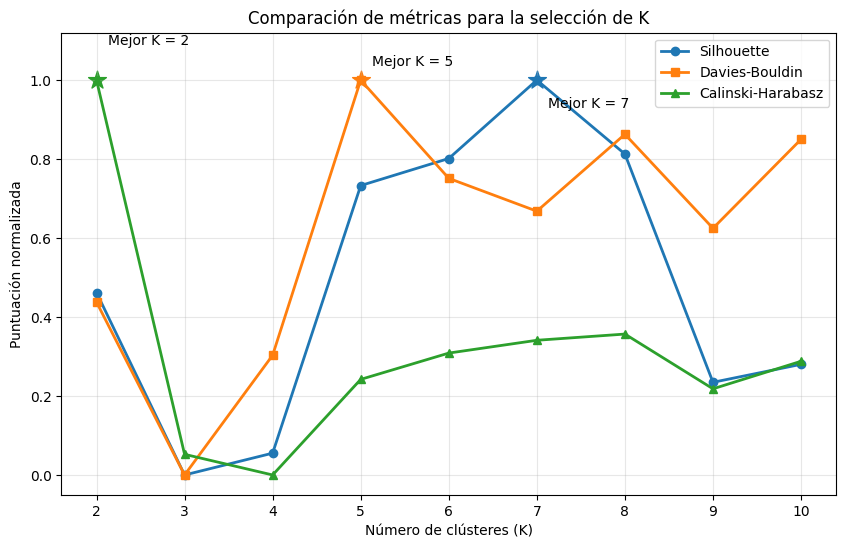

In [ ]:
# Comparamos las tres métricas

# Identificamos el mejor K de cada métrica

i_sil = metricas_grafica["Silhouette"].idxmax()
i_db = metricas_grafica["Davies-Bouldin"].idxmax()
i_ch = metricas_grafica["Calinski-Harabasz"].idxmax()

# Graficamos las tres métricas

plt.figure(figsize=(10, 6))

plt.plot(metricas_grafica["K"], metricas_grafica["Silhouette"], marker="o", linewidth=2, label="Silhouette")
plt.plot(metricas_grafica["K"], metricas_grafica["Davies-Bouldin"], marker="s", linewidth=2, label="Davies-Bouldin")
plt.plot(metricas_grafica["K"], metricas_grafica["Calinski-Harabasz"], marker="^", linewidth=2, label="Calinski-Harabasz")

# Marcamos los mejores valores

plt.scatter(metricas_grafica.loc[i_sil, "K"], metricas_grafica.loc[i_sil, "Silhouette"], s=180, marker="*")
plt.scatter(metricas_grafica.loc[i_db, "K"], metricas_grafica.loc[i_db, "Davies-Bouldin"], s=180, marker="*")
plt.scatter(metricas_grafica.loc[i_ch, "K"], metricas_grafica.loc[i_ch, "Calinski-Harabasz"], s=180, marker="*")

# Agregamos las etiquetas

plt.annotate(f"Mejor K = {int(metricas_grafica.loc[i_sil, 'K'])}",
             (metricas_grafica.loc[i_sil, "K"], metricas_grafica.loc[i_sil, "Silhouette"]),
             xytext=(8, -20), textcoords="offset points")

plt.annotate(f"Mejor K = {int(metricas_grafica.loc[i_db, 'K'])}",
             (metricas_grafica.loc[i_db, "K"], metricas_grafica.loc[i_db, "Davies-Bouldin"]),
             xytext=(8, 10), textcoords="offset points")

plt.annotate(f"Mejor K = {int(metricas_grafica.loc[i_ch, 'K'])}",
             (metricas_grafica.loc[i_ch, "K"], metricas_grafica.loc[i_ch, "Calinski-Harabasz"]),
             xytext=(8, 25), textcoords="offset points")

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Puntuación normalizada")
plt.title("Comparación de métricas para la selección de K")
plt.xticks(valores_k)
plt.ylim(-0.05, 1.12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Identificamos el mejor K según cada métrica

mejor_silhouette = metricas_k.loc[metricas_k["Silhouette"].idxmax(), "K"]
mejor_davies = metricas_k.loc[metricas_k["Davies-Bouldin"].idxmin(), "K"]
mejor_calinski = metricas_k.loc[metricas_k["Calinski-Harabasz"].idxmax(), "K"]

print("Silhouette          -> K =", mejor_silhouette, "(mayor es mejor)")
print("Davies-Bouldin      -> K =", mejor_davies, "(menor es mejor)")
print("Calinski-Harabasz   -> K =", mejor_calinski, "(mayor es mejor)")

Silhouette          -> K = 7 (mayor es mejor)
Davies-Bouldin      -> K = 5 (menor es mejor)
Calinski-Harabasz   -> K = 2 (mayor es mejor)


- Las métricas internas no coinciden en un único número óptimo de clústeres.

- Silhouette favorece K=7, Davies-Bouldin K=5 y Calinski-Harabasz K=2, por lo que la selección final de K requiere evaluar también la estabilidad de las particiones.

### **Análisis de estabilidad**

- Los criterios iniciales sugieren como candidatos K = 2, K = 5 y K = 7.

- Usaremos remuestreo y el Adjusted Rand Index (ARI) para evaluar si los clústeres se mantienen estables ante pequeñas variaciones de los datos.

- ARI cercano a 1 indica alta estabilidad, mientras que valores cercanos a 0 indican baja estabilidad.

- Seleccionaremos el K que presente una estructura de clústeres más estable.

In [ ]:
from sklearn.metrics import adjusted_rand_score

### Procedimiento de estabilidad

Para cada valor de K:

1. Ajustamos K-Means con todos los datos como referencia.
2. Seleccionamos aleatoriamente el 80 % de las observaciones.
3. Ajustamos nuevamente K-Means sobre la muestra.
4. Comparamos los clústeres mediante el índice ARI.
5. Repetimos el proceso 100 veces para evaluar la estabilidad.

In [ ]:
# Evaluamos la estabilidad de los candidatos
# Evaluamos la estabilidad para cada K

resultados = []
ari_completos = []

for k in candidatos:

    modelo_base = KMeans(n_clusters=k, n_init=30, random_state=42)
    etiquetas_base = modelo_base.fit_predict(X_kmeans)

    valores_ari = []

    for semilla in range(100):

        muestra = X_kmeans.sample(frac=0.80, replace=False, random_state=semilla)

        modelo = KMeans(n_clusters=k, n_init=30, random_state=semilla)
        etiquetas = modelo.fit_predict(muestra)

        referencia = etiquetas_base[muestra.index]
        ari = adjusted_rand_score(referencia, etiquetas)

        valores_ari.append(ari)
        ari_completos.append([k, ari])

    resultados.append([k, np.mean(valores_ari), np.median(valores_ari),
                       np.std(valores_ari), np.min(valores_ari), np.max(valores_ari)])

# Convertimos los resultados a Pandas

estabilidad_k = pd.DataFrame(resultados, columns=["K", "ARI medio", "ARI mediano",
                                                  "Desviación ARI", "ARI mínimo", "ARI máximo"])


In [ ]:
# Resumimos la estabilidad

estabilidad_k = pd.DataFrame(resultados_estabilidad)

estabilidad_k.round(3)

,K,ARI medio,ARI mediano,Desviación ARI,ARI mínimo
0,2,0.974,0.987,0.040,0.786
1,5,0.978,0.987,0.032,0.876
2,7,0.953,0.974,0.061,0.715


In [ ]:
ari_completos = pd.DataFrame(ari_completos, columns=["K", "ARI"])

ari_completos.head()

,K,ARI
0,2,0.950285
1,2,1.000000
2,2,1.000000
3,2,0.925942
4,2,0.974975


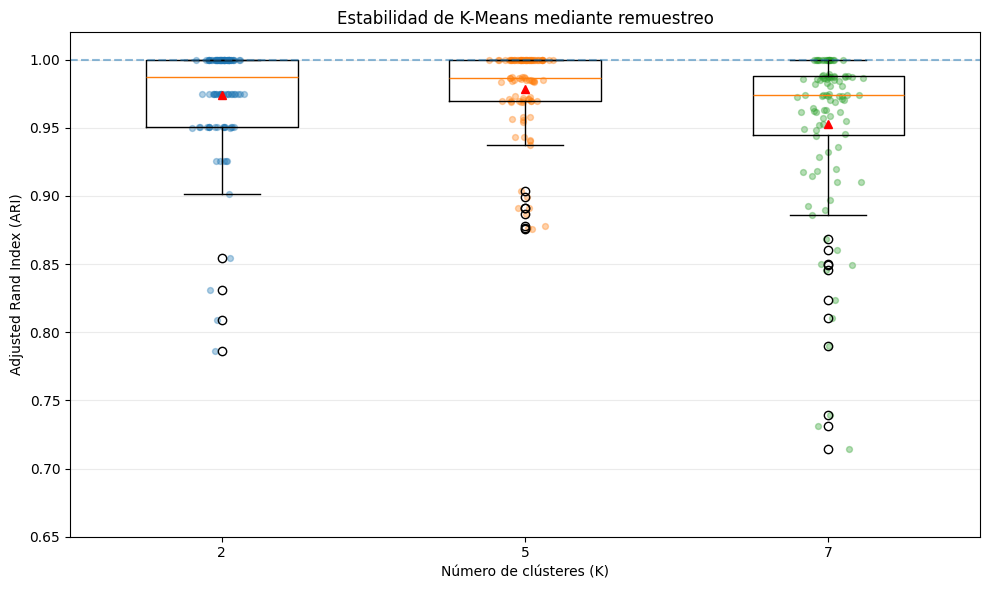

In [ ]:
# Dsitribucipn de la estabildiad

# Visualizamos la estabilidad de los candidatos

# Graficamos la estabilidad

# Visualizamos la estabilidad de K-Means

plt.figure(figsize=(10, 6))

datos = []

for k in candidatos:
    valores = ari_completos[ari_completos["K"] == k]["ARI"]
    datos.append(valores)

plt.boxplot(
    datos,
    tick_labels=candidatos,
    widths=0.5,
    showmeans=True,
    meanprops=dict(
        marker="^",
        markerfacecolor="red",
        markeredgecolor="red"
    )
)

# Mostramos las observaciones individuales

for i, k in enumerate(candidatos):
    valores = ari_completos[ari_completos["K"] == k]["ARI"]
    x = np.random.normal(i + 1, 0.035, len(valores))
    plt.scatter(x, valores, alpha=0.35, s=18)

plt.axhline(1, linestyle="--", alpha=0.5)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.title("Estabilidad de K-Means mediante remuestreo")

plt.ylim(0.65, 1.02)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretación de la estabilidad

- K = 5 presenta la mayor estabilidad, con valores de ARI altos y poca dispersión.

- K = 2 también muestra buena estabilidad, mientras que K = 7 presenta mayor variabilidad.

| Criterio | K favorecido |
|---|---:|
| Calinski-Harabasz | 2 |
| Davies-Bouldin | 5 |
| Silhouette | 7 |
| Estabilidad | 5 |

- Por ahora, K = 5 es el candidato más fuerte, pero debemos confirmar la decisión con las estadísticas del ARI.

## Robustez frente al tamaño de la muestra

In [ ]:
# Evaluamos la robustez para diferentes tamaños de muestra

fracciones = [0.60, 0.70, 0.80, 0.90]
resultados_robustez = []

for k in candidatos:

    modelo_base = KMeans(n_clusters=k, n_init=30, random_state=42)
    etiquetas_base = modelo_base.fit_predict(X_kmeans)

    for fraccion in fracciones:

        valores_ari = []

        for semilla in range(100):

            muestra = X_kmeans.sample(frac=fraccion, replace=False, random_state=semilla)

            modelo = KMeans(n_clusters=k, n_init=30, random_state=semilla)
            etiquetas = modelo.fit_predict(muestra)

            referencia = etiquetas_base[muestra.index]
            ari = adjusted_rand_score(referencia, etiquetas)

            valores_ari.append(ari)

        resultados_robustez.append([
            k,
            int(fraccion * 100),
            np.mean(valores_ari),
            np.median(valores_ari),
            np.std(valores_ari),
            np.min(valores_ari)
        ])

# Guardamos los resultados en Pandas

robustez_k = pd.DataFrame(resultados_robustez, columns=[
    "K",
    "Muestra (%)",
    "ARI medio",
    "ARI mediano",
    "Desviación ARI",
    "ARI mínimo"
])

robustez_k.round(3)

,K,Muestra (%),ARI medio,ARI mediano,Desviación ARI,ARI mínimo
0,2,60,0.928,0.967,0.078,0.692
1,2,70,0.953,0.971,0.059,0.733
2,2,80,0.974,0.987,0.040,0.786
3,2,90,0.983,1.000,0.030,0.829
4,5,60,0.950,0.978,0.063,0.643
5,5,70,0.962,0.981,0.044,0.833
6,5,80,0.978,0.987,0.032,0.876
7,5,90,0.990,1.000,0.021,0.867
8,7,60,0.894,0.914,0.076,0.668
9,7,70,0.914,0.937,0.074,0.705


### Ahora miramos estabilidad

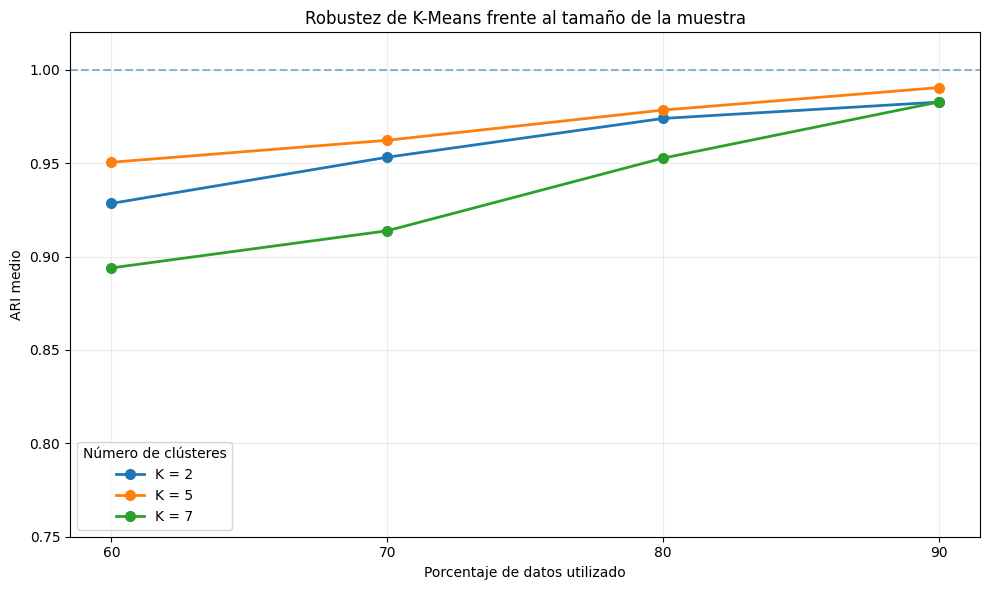

In [ ]:
# Comparamos la robustez de los candidatos

plt.figure(figsize=(10, 6))

for k in candidatos:

    datos = robustez_k[robustez_k["K"] == k]

    plt.plot(datos["Muestra (%)"], datos["ARI medio"],
             marker="o", linewidth=2, markersize=7, label=f"K = {k}")

plt.axhline(1, linestyle="--", alpha=0.5)

plt.xlabel("Porcentaje de datos utilizado")
plt.ylabel("ARI medio")
plt.title("Robustez de K-Means frente al tamaño de la muestra")

plt.xticks([60, 70, 80, 90])
plt.ylim(0.75, 1.02)

plt.legend(title="Número de clústeres")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

- K=5 presenta el mayor ARI medio en todos los tamaños de muestra evaluados, desde el 60 % hasta el 90 % de los datos.

- A medida que aumenta el tamaño de la muestra, su estabilidad mejora y la variabilidad disminuye, alcanzando un ARI medio de 0.990 con el 90 % de los datos.

- K=7 muestra mayor sensibilidad a la reducción del tamaño muestral, mientras que K=2 mantiene una estabilidad alta pero ligeramente inferior a K=5.

- Estos resultados aportan evidencia adicional a favor de K=5 como una solución robusta frente a cambios en el tamaño de la muestra.

## Robustez frente a la inicialización

- Evaluamos si K-Means produce grupos similares al cambiar la inicialización de los centroides.

- Primero generamos una partición de referencia para cada candidato y después hacemos 100 inicializaciones independientes.

In [ ]:
# Evaluamos la robustez frente a diferentes inicializaciones

resultados_inicializacion = []

for k in candidatos:

    modelo_base = KMeans(n_clusters=k, n_init=30, random_state=42)
    etiquetas_base = modelo_base.fit_predict(X_kmeans)

    valores_ari = []
    valores_inercia = []

    for semilla in range(100):

        modelo = KMeans(n_clusters=k, n_init=1, random_state=semilla)
        etiquetas = modelo.fit_predict(X_kmeans)

        ari = adjusted_rand_score(etiquetas_base, etiquetas)

        valores_ari.append(ari)
        valores_inercia.append(modelo.inertia_)

    resultados_inicializacion.append([
        k,
        np.mean(valores_ari),
        np.median(valores_ari),
        np.std(valores_ari),
        np.min(valores_ari),
        np.mean(valores_inercia),
        np.std(valores_inercia)
    ])

# Guardamos los resultados en Pandas

inicializacion_k = pd.DataFrame(resultados_inicializacion, columns=[
    "K",
    "ARI medio",
    "ARI mediano",
    "Desviación ARI",
    "ARI mínimo",
    "Inercia media",
    "Desviación inercia"
])

inicializacion_k.round(3)

,K,ARI medio,ARI mediano,Desviación ARI,ARI mínimo,Inercia media,Desviación inercia
0,2,1.000,1.000,0.000,1.000,584.175,0.000
1,5,0.773,0.756,0.186,0.276,312.042,20.326
2,7,0.823,0.818,0.122,0.476,222.362,13.092


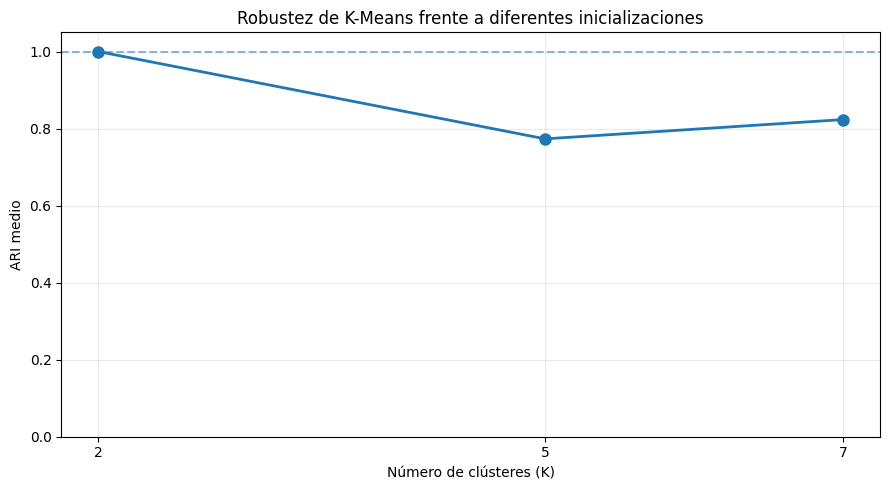

In [ ]:
# Comparamos la robustez frente a la inicialización

plt.figure(figsize=(9, 5))

plt.plot(inicializacion_k["K"], inicializacion_k["ARI medio"],
         marker="o", linewidth=2, markersize=8)

plt.axhline(1, linestyle="--", alpha=0.5)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("ARI medio")
plt.title("Robustez de K-Means frente a diferentes inicializaciones")

plt.xticks(candidatos)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

- K=2 presenta estabilidad perfecta frente a diferentes inicializaciones, obteniendo un ARI medio de 1 y variabilidad nula.

- K=5 y K=7 son más sensibles a la posición inicial de los centroides cuando K-Means se ejecuta con una sola inicialización.

- La sensibilidad observada en K=5 justifica utilizar múltiples inicializaciones (`n_init=30`) en el modelo final para reducir el riesgo de converger a soluciones locales deficientes.

### Comparación de los candidatos

| Criterio | K = 2 | K = 5 | K = 7 |
|---|---:|---:|---:|
| Calinski-Harabasz | ✓ | | |
| Davies-Bouldin | | ✓ | |
| Silhouette | | | ✓ |
| Robustez al remuestreo | Alta | Muy alta | Menor |
| Robustez a inicialización | Excelente | Moderada | Moderada-alta |

- K = 5 destaca por su alta estabilidad ante cambios en los datos.

- K = 2 destaca por su excelente estabilidad ante diferentes inicializaciones.

- K = 7 pierde fuerza debido a su menor estabilidad frente al remuestreo.

### Gap Statistic

- Compara la estructura de nuestros clústeres con datos de referencia sin una estructura de agrupamiento definida.

- Valores altos de Gap indican una mejor separación de los clústeres.

- La selección de K se realiza utilizando la regla de Tibshirani:

$Gap(K)\geq Gap(K+1)-s_{K+1}$

In [ ]:
# Calculamos Gap Statistic

valores_k = range(2, 11)
B = 100

gap_resultados = []

minimos = X_kmeans.min(axis=0).values
maximos = X_kmeans.max(axis=0).values

for k in valores_k:

    modelo = KMeans(n_clusters=k, n_init=30, random_state=42)
    modelo.fit(X_kmeans)

    log_inercia_real = np.log(modelo.inertia_)

    inercias_referencia = []

    for b in range(B):

        np.random.seed(b)

        referencia = np.random.uniform(
            low=minimos,
            high=maximos,
            size=X_kmeans.shape
        )

        modelo_ref = KMeans(n_clusters=k, n_init=30, random_state=42)
        modelo_ref.fit(referencia)

        inercias_referencia.append(np.log(modelo_ref.inertia_))

    gap = np.mean(inercias_referencia) - log_inercia_real

    desviacion = np.std(inercias_referencia, ddof=1)
    error_gap = desviacion * np.sqrt(1 + 1 / B)

    gap_resultados.append([k, gap, error_gap])

# Guardamos los resultados en Pandas

gap_k = pd.DataFrame(
    gap_resultados,
    columns=["K", "Gap", "Error"]
)

gap_k.round(3)

,K,Gap,Error
0,2,0.423,0.039
1,3,0.392,0.040
2,4,0.411,0.035
3,5,0.468,0.035
4,6,0.481,0.033
5,7,0.502,0.035
6,8,0.517,0.034
7,9,0.506,0.033
8,10,0.538,0.034


### Regla de decisión

In [ ]:
# Aplicamos la regla de selección de Gap Statistic

seleccion_gap = []

for i in range(len(gap_k) - 1):

    k = gap_k.loc[i, "K"]
    gap_actual = gap_k.loc[i, "Gap"]

    gap_siguiente = gap_k.loc[i + 1, "Gap"]
    error_siguiente = gap_k.loc[i + 1, "Error"]

    cumple = gap_actual >= gap_siguiente - error_siguiente

    seleccion_gap.append([k, cumple])

regla_gap = pd.DataFrame(
    seleccion_gap,
    columns=["K", "Cumple regla"]
)

regla_gap

,K,Cumple regla
0,2,True
1,3,True
2,4,False
3,5,True
4,6,True
5,7,True
6,8,True
7,9,True


In [ ]:
# K seleccionado por la regla de Gap Statistic

k_gap = regla_gap.loc[regla_gap["Cumple regla"], "K"].iloc[0]

print("K seleccionado por Gap Statistic:", k_gap)

K seleccionado por Gap Statistic: 2


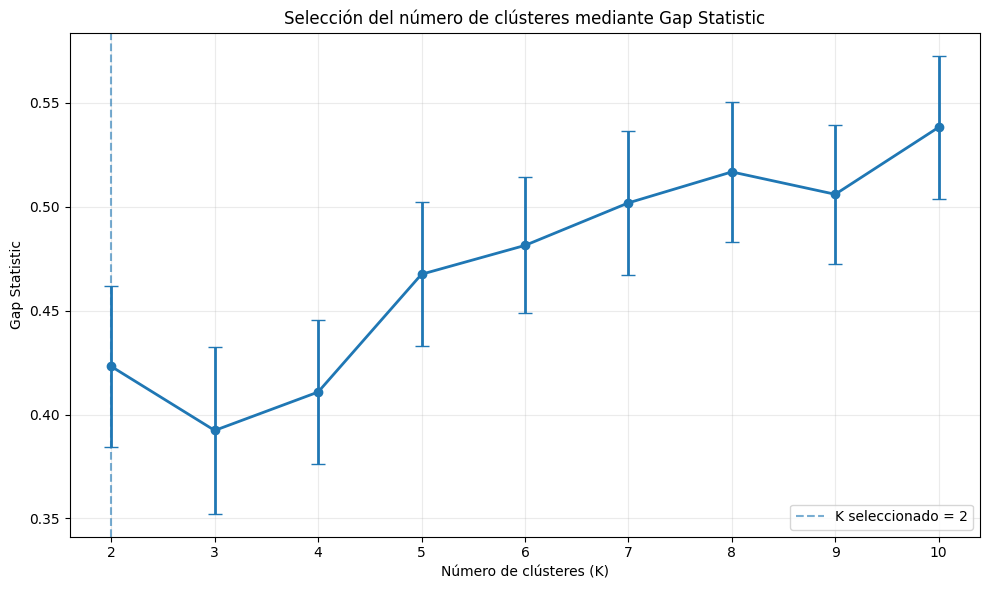

In [ ]:
# Graficamos Gap Statistic

plt.figure(figsize=(10, 6))

plt.errorbar(
    gap_k["K"],
    gap_k["Gap"],
    yerr=gap_k["Error"],
    marker="o",
    linewidth=2,
    capsize=5
)

plt.axvline(
    k_gap,
    linestyle="--",
    alpha=0.6,
    label=f"K seleccionado = {k_gap}"
)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Gap Statistic")
plt.title("Selección del número de clústeres mediante Gap Statistic")

plt.xticks(gap_k["K"])
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Comparación de los criterios para seleccionar K

| Criterio | K favorecido | Interpretación |
|---|---:|---|
| Método del codo | No concluyente | No presenta un codo suficientemente claro |
| Silhouette | 7 | Mejor cohesión y separación |
| Davies-Bouldin | 5 | Clústeres más compactos y separados |
| Calinski-Harabasz | 2 | Favorece una estructura global de 2 grupos |
| Estabilidad por remuestreo | 5 | Alta estabilidad ante cambios en los datos |
| Robustez 60–90 % | 5 | Mayor consistencia al variar el tamaño de la muestra |
| Robustez a inicialización | 2 | Mantiene la misma partición entre inicializaciones |
| Gap Statistic | 2 | Favorece la solución más parsimoniosa |

- Los criterios no identifican un único valor de K como ganador absoluto.

- K=2 presenta la mayor evidencia de parsimonia y estabilidad frente a la inicialización, mientras que K=5 presenta mayor robustez frente al remuestreo y a cambios en el tamaño de la muestra.

- K=7, aunque obtiene el mejor Silhouette, recibe menor respaldo de las demás pruebas y presenta mayor sensibilidad al remuestreo.

- La comparación final se concentra, por tanto, en K=2 y K=5 para determinar si los cinco clústeres representan grupos realmente diferenciados o subdivisiones de una estructura principal de dos grupos.

- Los criterios evaluados no identificaron un único valor de K como óptimo bajo todas las métricas.

- K=2 mostró la mayor parsimonia y estabilidad frente a diferentes inicializaciones, mientras que K=7 obtuvo el mejor Silhouette pero presentó mayor sensibilidad al remuestreo.

- K=5 presentó el mejor compromiso entre compactación y robustez: fue favorecido por Davies-Bouldin y obtuvo el mayor ARI medio en todos los tamaños de muestra evaluados.

- Por estas razones se selecciona K=5 para el modelo final. La sensibilidad observada frente a inicializaciones individuales se controla utilizando múltiples inicializaciones en K-Means (`n_init=30`).

In [ ]:
# Resumimos los criterios que favorecen a cada K

respaldo = pd.DataFrame({
    "K": [2, 5, 7],
    "Criterios favorables": [3, 3, 1]
})

respaldo

,K,Criterios favorables
0,2,3
1,5,3
2,7,1


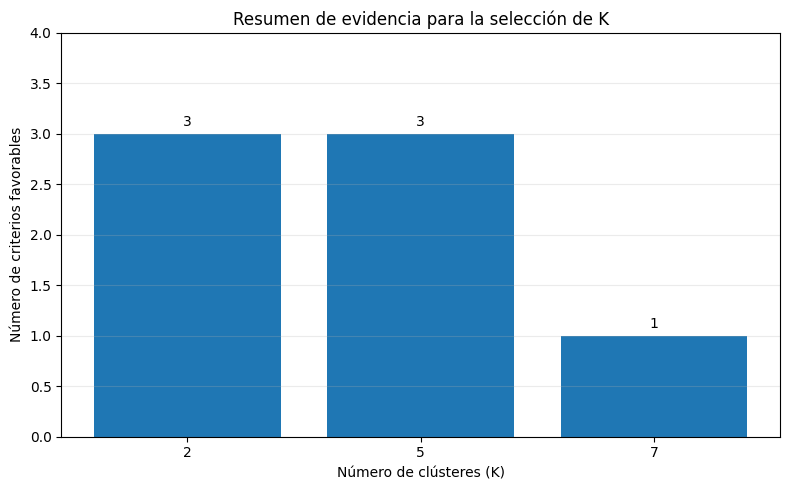

In [ ]:
# Graficamos el respaldo obtenido por cada candidato

plt.figure(figsize=(8, 5))

barras = plt.bar(
    respaldo["K"].astype(str),
    respaldo["Criterios favorables"]
)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Número de criterios favorables")
plt.title("Resumen de evidencia para la selección de K")

plt.ylim(0, 4)
plt.grid(axis="y", alpha=0.25)

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.08,
        str(int(altura)),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Ajustamos K-Means para K = 2 y K = 5

modelo_k2 = KMeans(n_clusters=2, n_init=30, random_state=42)
modelo_k5 = KMeans(n_clusters=5, n_init=30, random_state=42)

cluster_k2 = modelo_k2.fit_predict(X_kmeans)
cluster_k5 = modelo_k5.fit_predict(X_kmeans)

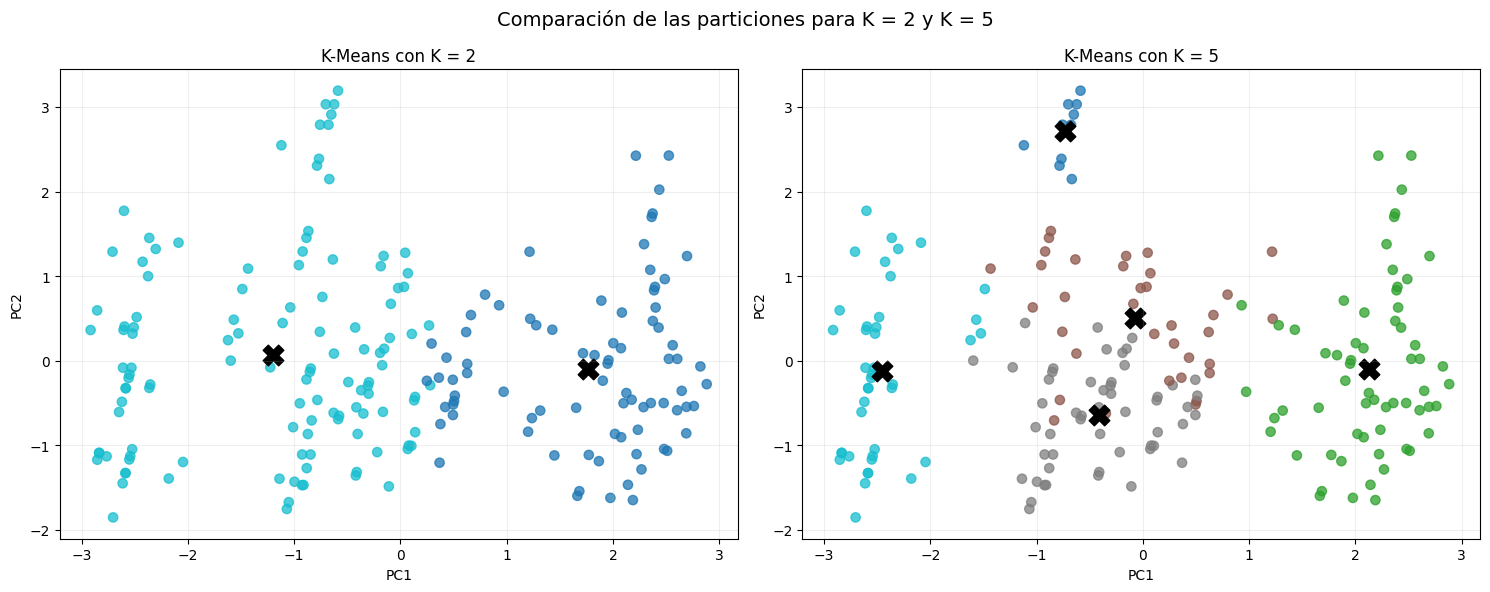

In [ ]:
# Comparamos K = 2 y K = 5 en PC1 y PC2

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

ejes[0].scatter(
    X_kmeans["PC1"],
    X_kmeans["PC2"],
    c=cluster_k2,
    cmap="tab10",
    s=45,
    alpha=0.75
)

ejes[0].scatter(
    modelo_k2.cluster_centers_[:, 0],
    modelo_k2.cluster_centers_[:, 1],
    marker="X",
    s=220,
    c="black"
)

ejes[0].set_xlabel("PC1")
ejes[0].set_ylabel("PC2")
ejes[0].set_title("K-Means con K = 2")
ejes[0].grid(alpha=0.2)


ejes[1].scatter(
    X_kmeans["PC1"],
    X_kmeans["PC2"],
    c=cluster_k5,
    cmap="tab10",
    s=45,
    alpha=0.75
)

ejes[1].scatter(
    modelo_k5.cluster_centers_[:, 0],
    modelo_k5.cluster_centers_[:, 1],
    marker="X",
    s=220,
    c="black"
)

ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")
ejes[1].set_title("K-Means con K = 5")
ejes[1].grid(alpha=0.2)

plt.suptitle("Comparación de las particiones para K = 2 y K = 5", fontsize=14)

plt.tight_layout()
plt.show()

- K=2 identifica una estructura global formada por dos grandes regiones, principalmente diferenciadas a lo largo de PC1.

- K=5 revela una segmentación más detallada del espacio PCA, incluyendo grupos diferenciados tanto en PC1 como en PC2.

- La comparación visual sugiere que K=5 no solo divide arbitrariamente los dos grupos principales, sino que captura subestructuras adicionales presentes en los datos.

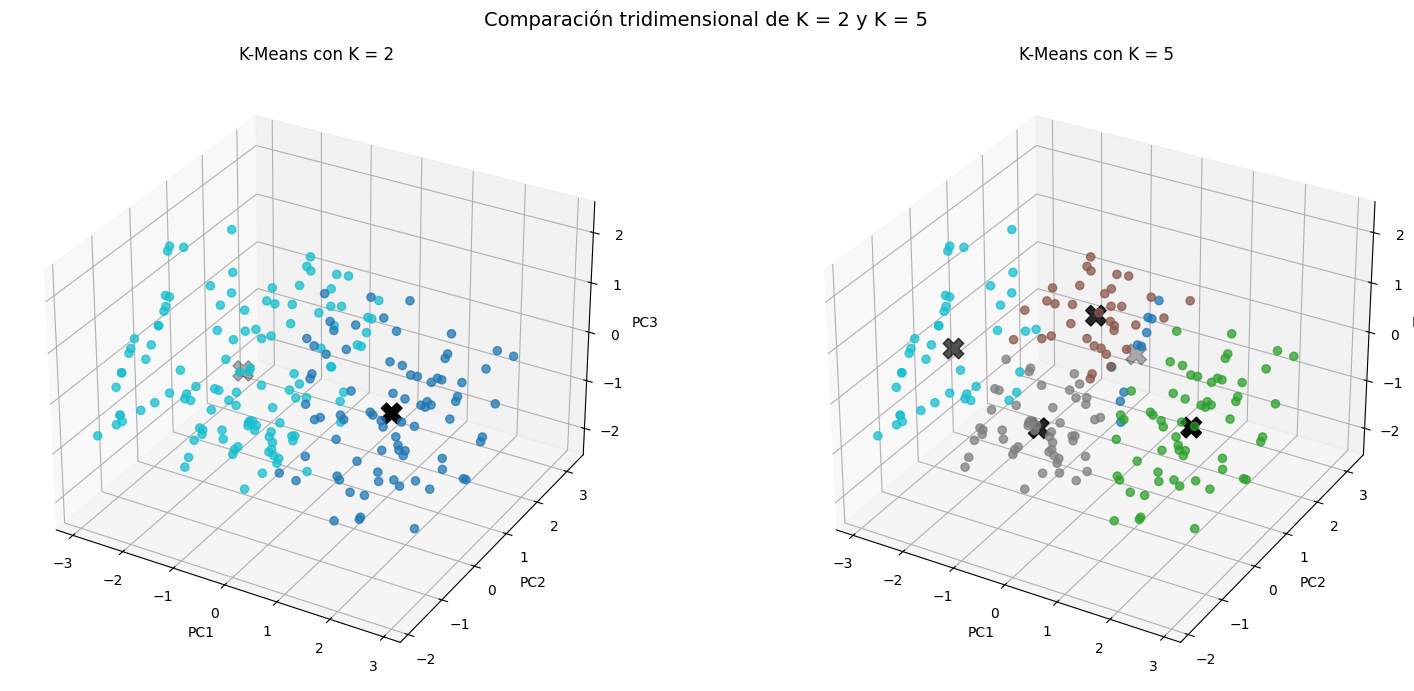

In [ ]:
# Comparamos K = 2 y K = 5 en PC1, PC2 y PC3

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection="3d")

ax1.scatter(
    X_kmeans["PC1"],
    X_kmeans["PC2"],
    X_kmeans["PC3"],
    c=cluster_k2,
    cmap="tab10",
    s=35,
    alpha=0.75
)

ax1.scatter(
    modelo_k2.cluster_centers_[:, 0],
    modelo_k2.cluster_centers_[:, 1],
    modelo_k2.cluster_centers_[:, 2],
    c="black",
    marker="X",
    s=220
)

ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")
ax1.set_title("K-Means con K = 2")


ax2 = fig.add_subplot(122, projection="3d")

ax2.scatter(
    X_kmeans["PC1"],
    X_kmeans["PC2"],
    X_kmeans["PC3"],
    c=cluster_k5,
    cmap="tab10",
    s=35,
    alpha=0.75
)

ax2.scatter(
    modelo_k5.cluster_centers_[:, 0],
    modelo_k5.cluster_centers_[:, 1],
    modelo_k5.cluster_centers_[:, 2],
    c="black",
    marker="X",
    s=220
)

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("K-Means con K = 5")

plt.suptitle("Comparación tridimensional de K = 2 y K = 5", fontsize=14)

plt.tight_layout()
plt.show()

- K=2 identifica una estructura global formada por dos grandes regiones, principalmente diferenciadas a lo largo de PC1.

- K=5 revela una segmentación más detallada del espacio PCA, incluyendo grupos diferenciados tanto en PC1 como en PC2.

- La comparación visual sugiere que K=5 no solo divide arbitrariamente los dos grupos principales, sino que captura subestructuras adicionales presentes en los datos.

### Decisión final: K=2 vs. K=5

| Criterio | 🟠 K=2 | 🔵 K=5 |
|---|---|---|
| Estructura encontrada | Dos grupos globales | Cinco grupos más detallados |
| Calinski-Harabasz | 🟠 Favorecido | — |
| Davies-Bouldin | — | 🔵 Favorecido |
| Gap Statistic | 🟠 Favorecido | — |
| Estabilidad ante inicializaciones | 🟠 Excelente, ARI = 1.000 | Sensible con una sola inicialización |
| Robustez al remuestreo | Alta | 🔵 Muy alta |
| Robustez 60–90 % | Alta | 🔵 Mayor ARI medio en los cuatro escenarios |
| Visualización 2D | Dos regiones principales | 🔵 Identifica subestructuras adicionales |
| Visualización 3D | Mantiene la estructura global | 🔵 Mantiene una segmentación más detallada |

<br>

🟠 **K=2 — estructura global**

K=2 representa la solución más simple y parsimoniosa. Presenta una estabilidad perfecta frente a diferentes inicializaciones y además es respaldado por Calinski-Harabasz y Gap Statistic. Por tanto, existe evidencia de una estructura global formada por dos grandes grupos.

🔵 **K=5 — estructura detallada**

K=5 proporciona una segmentación más fina. Es favorecido por Davies-Bouldin, presenta el mayor ARI medio para todos los tamaños de muestra evaluados (60 %, 70 %, 80 % y 90 %) y mantiene una estructura diferenciada en las representaciones 2D y 3D del espacio PCA.

### 🔵 Decisión final

Se selecciona **K=5** como número final de clústeres, ya que ofrece un mejor compromiso entre separación, robustez frente al remuestreo y capacidad para identificar perfiles más detallados en los datos de la clínica.

La solución **K=2 no se considera incorrecta**: representa una estructura global más parsimoniosa. Sin embargo, para el objetivo de segmentación y posterior caracterización de los grupos, **K=5 proporciona una representación más informativa de la heterogeneidad de los datos**.

$$
\boxed{K=5}
$$

### 8.3. Aplicación de K-Means

In [ ]:
# Aplicamos el modelo final de K-Means

kmeans_final = KMeans(
    n_clusters=5,
    n_init=30,
    random_state=42
)

clusters = kmeans_final.fit_predict(X_kmeans)

In [ ]:
# Agregamos el clúster asignado a cada observación

pca_clusters = pca_df.copy()

pca_clusters["Cluster"] = clusters

pca_clusters.head()

,PC1,PC2,PC3,Cluster
0,-0.164140,-0.604352,-0.077520,3
1,-1.036060,0.630276,0.359069,2
2,-2.045545,-1.197327,-0.195635,4
3,2.478005,-0.500224,1.273790,1
4,-2.703830,-1.852240,-0.660544,4


In [ ]:
# Contamos las observaciones de cada clúster

tamaño_clusters = pca_clusters["Cluster"].value_counts().sort_index()

tamaño_clusters = pd.DataFrame({
    "Cluster": tamaño_clusters.index,
    "Observaciones": tamaño_clusters.values
})

tamaño_clusters["Porcentaje"] = (
    tamaño_clusters["Observaciones"] / len(pca_clusters) * 100
)

tamaño_clusters.round(2)

,Cluster,Observaciones,Porcentaje
0,0,10,5.0
1,1,62,31.0
2,2,35,17.5
3,3,52,26.0
4,4,41,20.5


In [ ]:
# Centroides del modelo final

centroides = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=["PC1", "PC2", "PC3"]
)

centroides.index.name = "Cluster"

centroides.round(3)

,PC1,PC2,PC3
Cluster,,,
0,-0.733,2.714,-1.153
1,2.130,-0.100,-0.075
2,-0.075,0.502,1.117
3,-0.414,-0.645,-0.542
4,-2.453,-0.122,0.128


- Los cinco clústeres contienen observaciones, aunque tienen tamaños diferentes; el clúster 0 es el más pequeño y deberá revisarse con atención.

- Los centroides muestran que los grupos se diferencian mediante PC1, PC2 y PC3, lo que evidencia una estructura de agrupamiento bien definida.

- Para interpretar el significado de cada clúster debemos regresar a los loadings y a las variables originales.

## 9. Visualización de los clústeres

### 9.1. Visualización de los clústeres mediante PC1 y PC2



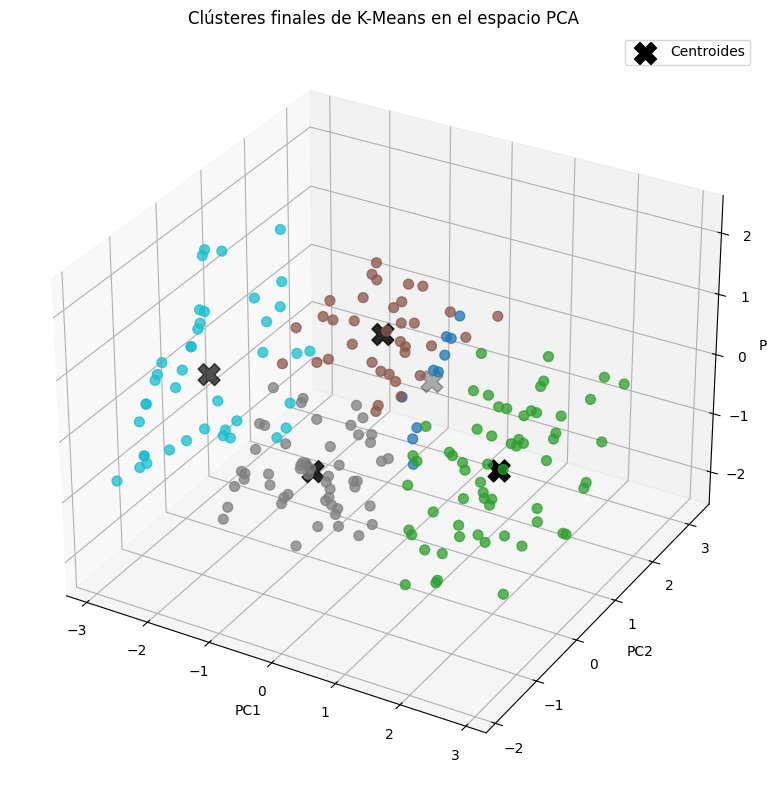

In [ ]:
# Visualizamos los clústeres en tres dimensiones

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

grafico = ax.scatter(
    pca_clusters["PC1"],
    pca_clusters["PC2"],
    pca_clusters["PC3"],
    c=pca_clusters["Cluster"],
    cmap="tab10",
    s=50,
    alpha=0.75
)

# Agregamos los centroides

ax.scatter(
    centroides["PC1"],
    centroides["PC2"],
    centroides["PC3"],
    c="black",
    marker="X",
    s=250,
    label="Centroides"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("Clústeres finales de K-Means en el espacio PCA")

ax.legend()

plt.tight_layout()
plt.show()

## 10. Perfil de los clústeres

### 10.1. Perfil promedio de cada clúster


### Perfil de los clústeres

- Regresamos a las variables originales para entender qué características definen cada clúster.

- Utilizamos los datos sin estandarizar para interpretar los resultados en sus unidades reales.

- Calculamos el promedio de edad, duración, costo, dosis, días de tratamiento y satisfacción para cada clúster.





In [ ]:
# Agregamos los clústeres a los datos originales

datos_clusters = df.copy()

datos_clusters["Cluster"] = clusters

In [ ]:
# Variables utilizadas para construir los clústeres

variables_numericas = [
    "edad",
    "duracion_min",
    "costo_cita",
    "dosis_mg",
    "dias_tratamiento",
    "satisfaccion"
]

In [ ]:
# Calculamos el promedio de cada variable por clúster

perfil_clusters = datos_clusters.groupby("Cluster")[variables_numericas].mean()

perfil_clusters.round(2)

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
Cluster,,,,,,
0,41.10,35.00,205000.00,600.00,90.00,5.00
1,40.31,53.63,312741.94,146.05,50.48,3.15
2,53.06,37.57,221428.57,155.71,37.14,4.26
3,29.58,35.48,210384.62,107.52,36.73,4.21
4,36.66,22.32,129756.10,241.82,7.15,5.00


### Perfil de los clústeres

- Clúster 0 (n = 10): tratamientos intensivos y prolongados, con dosis de 600 mg, 90 días de tratamiento y satisfacción de 5.00.

- Clúster 1 (n = 62): consultas largas y costosas, con duración de 53.63 min, costo de $312,742 y menor satisfacción (3.15).

- Clúster 2 (n = 35): pacientes de mayor edad, con promedio de 53.06 años y satisfacción de 4.26.

- Clúster 3 (n = 52): pacientes más jóvenes, con edad promedio de 29.58 años y dosis de 107.52 mg.

- Clúster 4 (n = 41): consultas cortas y económicas, con duración de 22.32 min, costo de $129,756, tratamientos de 7.15 días y satisfacción de 5.00.

- Los cinco clústeres presentan perfiles diferentes en las variables originales.

- El clúster 0 concentra tratamientos de mayor dosis y duración, mientras que el clúster 4 presenta consultas más cortas, de menor costo y tratamientos más breves.

- El clúster 1 se caracteriza por consultas más largas y costosas y presenta la menor satisfacción promedio.

- Los clústeres 2 y 3 se diferencian principalmente por la edad, representando respectivamente los pacientes de mayor y menor edad.

### 10.2. Especialidad predominante en cada clúster

In [ ]:
# Buscamos la especialidad predominante en cada clúster

especialidad_cluster = (
    datos_clusters
    .groupby("Cluster")["especialidad"]
    .agg(lambda x: x.value_counts().index[0])
)

especialidad_cluster = pd.DataFrame(especialidad_cluster)

especialidad_cluster.columns = ["Especialidad predominante"]

especialidad_cluster

,Especialidad predominante
Cluster,
0,Ginecología
1,Neurología
2,Ortopedia
3,Dermatología
4,Pediatría


In [ ]:
# Calculamos la frecuencia de cada especialidad

frecuencia_especialidad = (
    datos_clusters
    .groupby(["Cluster", "especialidad"])
    .size()
    .reset_index(name="Frecuencia")
)

# Buscamos la especialidad con mayor frecuencia en cada clúster

predominante = (
    frecuencia_especialidad
    .sort_values(["Cluster", "Frecuencia"], ascending=[True, False])
    .drop_duplicates("Cluster")
)

# Calculamos el porcentaje dentro de cada clúster

tamaños = datos_clusters.groupby("Cluster").size()

predominante["Porcentaje"] = predominante.apply(
    lambda fila: fila["Frecuencia"] / tamaños[fila["Cluster"]] * 100,
    axis=1
)

predominante.round(2)

,Cluster,especialidad,Frecuencia,Porcentaje
0,0,Ginecología,10,100.00
3,1,Neurología,33,53.23
8,2,Ortopedia,14,40.00
10,3,Dermatología,22,42.31
15,4,Pediatría,35,85.37


- El clúster 0 presenta una asociación completa con Ginecología, que representa el 100 % de sus observaciones.

- El clúster 4 también muestra una especialización marcada: Pediatría representa el 85.37 % del grupo.

- Neurología es predominante en el clúster 1 con 53.23 %, mientras que los clústeres 2 y 3 presentan mayor heterogeneidad, ya que sus especialidades predominantes alcanzan solo el 40.00 % y 42.31 %, respectivamente.

- Los resultados muestran que algunos clústeres están fuertemente relacionados con determinadas especialidades, mientras que otros parecen estar definidos principalmente por las características numéricas utilizadas en PCA y K-Means.

## 11. Comparación del análisis con y sin escalado

### 11.1. PCA sin escalado





In [ ]:
# Seleccionamos las variables originales sin escalado

X_sin_escalar = df[
    [
        "edad",
        "duracion_min",
        "costo_cita",
        "dosis_mg",
        "dias_tratamiento",
        "satisfaccion"
    ]
].copy()

X_sin_escalar.head()

,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,34,45,250000.0,50.0,30,5
1,45,30,180000.0,400.0,10,4
2,28,25,150000.0,20.0,15,5
3,52,60,320000.0,50.0,20,3
4,19,20,120000.0,0.5,1,5


In [ ]:
# Aplicamos PCA directamente sobre los datos originales

pca_sin_escalar = PCA(n_components=3)

X_pca_sin_escalar = pca_sin_escalar.fit_transform(X_sin_escalar)

pca_sin_escalar_df = pd.DataFrame(
    X_pca_sin_escalar,
    columns=["PC1", "PC2", "PC3"],
    index=X_sin_escalar.index
)

pca_sin_escalar_df.head()

,PC1,PC2,PC3
0,22750.038301,-123.280262,-8.170638
1,-47250.070078,204.791654,-25.429008
2,-77249.950827,-184.191708,-6.496764
3,92750.034542,-102.086737,-28.956205
4,-107249.945751,-213.231099,-15.402432


In [ ]:
# Calculamos la varianza explicada

varianza_sin_escalar = []

for i in range(3):

    componente = "PC" + str(i + 1)
    proporcion = pca_sin_escalar.explained_variance_ratio_[i]
    porcentaje = proporcion * 100

    varianza_sin_escalar.append([
        componente,
        proporcion,
        porcentaje
    ])

# Guardamos los resultados en Pandas

varianza_sin_escalar = pd.DataFrame(
    varianza_sin_escalar,
    columns=["Componente", "Varianza explicada", "Porcentaje"]
)

varianza_sin_escalar.round(3)

,Componente,Varianza explicada,Porcentaje
0,PC1,1.0,99.999
1,PC2,0.0,0.001
2,PC3,0.0,0.000


In [ ]:

# Calculamos los loadings

loadings_sin_escalar = pd.DataFrame(
    pca_sin_escalar.components_.T,
    index=X_sin_escalar.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings_sin_escalar.round(3)

,PC1,PC2,PC3
edad,0.0,0.004,0.025
duracion_min,0.0,0.000,0.003
costo_cita,1.0,0.000,-0.000
dosis_mg,-0.0,1.000,-0.025
dias_tratamiento,0.0,0.025,0.999
satisfaccion,-0.0,0.001,0.001


- Sin escalado, **PC1 explica el 99.999 % de la varianza** y está prácticamente determinada por `costo_cita`, cuyo loading es 1.000.

- El resultado no implica que el costo sea necesariamente la variable más importante, sino que su escala numérica domina el cálculo de PCA.

- PC2 está dominada por `dosis_mg` y PC3 por `dias_tratamiento`, mientras que variables como edad, duración y satisfacción tienen una contribución muy reducida.

- Esto confirma la importancia de estandarizar las variables antes de aplicar PCA cuando se encuentran medidas en escalas diferentes.

### 11.2. K-Means sin escalado



In [ ]:
# Aplicamos K-Means sobre el PCA sin escalado

kmeans_sin_escalar = KMeans(
    n_clusters=5,
    n_init=30,
    random_state=42
)

clusters_sin_escalar = kmeans_sin_escalar.fit_predict(
    pca_sin_escalar_df
)

In [ ]:
# Revisamos el tamaño de los clústeres

tamaño_sin_escalar = []

for cluster in range(5):

    cantidad = np.sum(clusters_sin_escalar == cluster)
    porcentaje = cantidad / len(clusters_sin_escalar) * 100

    tamaño_sin_escalar.append([
        cluster,
        cantidad,
        porcentaje
    ])

# Guardamos los resultados en Pandas

tamaño_sin_escalar = pd.DataFrame(
    tamaño_sin_escalar,
    columns=["Cluster", "Observaciones", "Porcentaje"]
)

tamaño_sin_escalar.round(2)

,Cluster,Observaciones,Porcentaje
0,0,38,19.0
1,1,62,31.0
2,2,37,18.5
3,3,35,17.5
4,4,28,14.0


In [ ]:
# Calculamos la inercia para diferentes valores de K

valores_k = range(2, 11)
inercias_sin_escalar = []

for k in valores_k:

    modelo = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=42
    )

    modelo.fit(pca_sin_escalar_df)

    inercias_sin_escalar.append(modelo.inertia_)

# Guardamos los resultados en Pandas

codo_sin_escalar = pd.DataFrame({
    "K": list(valores_k),
    "Inercia": inercias_sin_escalar
})

codo_sin_escalar.round(2)

,K,Inercia
0,2,2.226543e+11
1,3,1.095686e+11
2,4,3.740369e+10
3,5,2.408763e+10
4,6,1.441791e+10
5,7,1.129300e+10
6,8,8.598845e+09
7,9,6.524519e+09
8,10,5.129818e+09


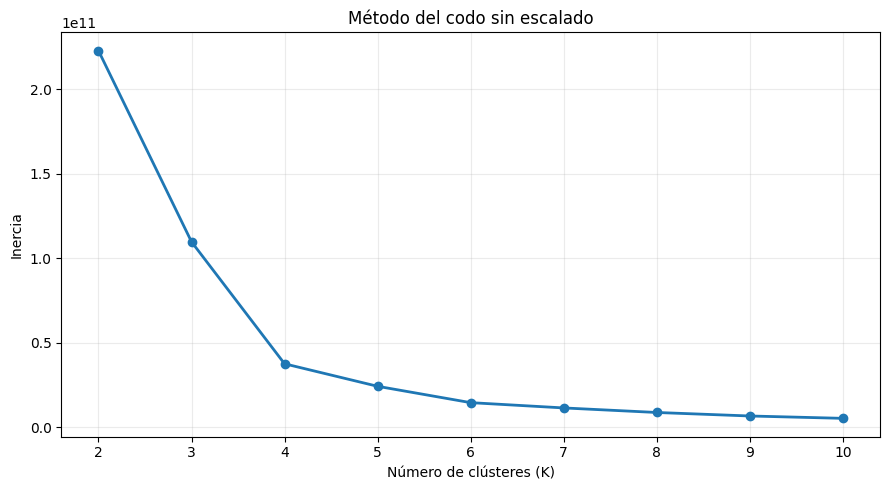

In [ ]:
# Graficamos el método del codo

plt.figure(figsize=(9, 5))

plt.plot(
    codo_sin_escalar["K"],
    codo_sin_escalar["Inercia"],
    marker="o",
    linewidth=2
)

plt.xlabel("Número de clústeres (K)")
plt.ylabel("Inercia")
plt.title("Método del codo sin escalado")

plt.xticks(codo_sin_escalar["K"])
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluamos diferentes valores de K

metricas_sin_escalar = []

for k in valores_k:

    modelo = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=42
    )

    etiquetas = modelo.fit_predict(pca_sin_escalar_df)

    silhouette = silhouette_score(
        pca_sin_escalar_df,
        etiquetas
    )

    davies = davies_bouldin_score(
        pca_sin_escalar_df,
        etiquetas
    )

    calinski = calinski_harabasz_score(
        pca_sin_escalar_df,
        etiquetas
    )

    metricas_sin_escalar.append([
        k,
        silhouette,
        davies,
        calinski
    ])

# Guardamos los resultados en Pandas

metricas_sin_escalar = pd.DataFrame(
    metricas_sin_escalar,
    columns=[
        "K",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

metricas_sin_escalar.round(3)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.670,0.469,697.136
1,3,0.617,0.548,806.409
2,4,0.716,0.347,1692.894
3,5,0.732,0.335,1988.458
4,6,0.706,0.406,2670.045
5,7,0.700,0.439,2834.991
6,8,0.712,0.433,3183.405
7,9,0.710,0.464,3659.531
8,10,0.721,0.450,4121.401


In [ ]:
# Identificamos el mejor K según cada métrica

k_silhouette = metricas_sin_escalar.loc[
    metricas_sin_escalar["Silhouette"].idxmax(),
    "K"
]

k_davies = metricas_sin_escalar.loc[
    metricas_sin_escalar["Davies-Bouldin"].idxmin(),
    "K"
]

k_calinski = metricas_sin_escalar.loc[
    metricas_sin_escalar["Calinski-Harabasz"].idxmax(),
    "K"
]

print("Silhouette         -> K =", k_silhouette)
print("Davies-Bouldin     -> K =", k_davies)
print("Calinski-Harabasz  -> K =", k_calinski)

Silhouette         -> K = 5
Davies-Bouldin     -> K = 5
Calinski-Harabasz  -> K = 10


In [ ]:
# Comparamos las particiones con y sin escalado

ari_comparacion = adjusted_rand_score(
    clusters,
    clusters_sin_escalar
)

print("ARI entre las particiones:", round(ari_comparacion, 3))

ARI entre las particiones: 0.638


### Comparación con y sin escalado

| Criterio | Con escalado | Sin escalado | Cambio |
|---|---:|---:|---|
| Codo | No concluyente | ≈ 4 | Sí |
| Silhouette | 7 | 5 | Sí |
| Davies-Bouldin | 5 | 5 | No |
| Calinski-Harabasz | 2 | 10 | Sí |

- Los resultados cambian considerablemente cuando no se escalan los datos.

- Sin escalado, costo_cita domina el PCA y PC1 explica prácticamente el 100 % de la variabilidad.

- Esto confirma la importancia de escalar las variables antes de aplicar PCA y K-Means.

## 12. Interpretación de los resultados





### 12.1. Acciones concretas para la clínica



### Acciones concretas para la clínica

- **Clúster 0:** presenta dosis de 600 mg, tratamientos de 90 días y satisfacción de 5.00. El 100 % corresponde a Ginecología. Se recomienda revisar las características de este perfil de tratamientos intensivos y prolongados.

- **Clúster 1:** presenta la mayor duración de consulta (53.63 min), el mayor costo ($312,741.94) y la menor satisfacción (3.15). Neurología representa el 53.23 %. Se recomienda analizar los factores asociados con la duración, el costo y la satisfacción.

- **Clúster 2:** presenta la mayor edad promedio (53.06 años) y Ortopedia representa el 40 %. Se recomienda analizar las características de atención asociadas con pacientes de mayor edad.

- **Clúster 3:** presenta la menor edad promedio (29.58 años) y Dermatología representa el 42.31 %. Se recomienda analizar las características de atención y tratamiento de los pacientes más jóvenes.

- **Clúster 4:** presenta consultas cortas (22.32 min), el menor costo ($129,756.10), tratamientos breves (7.15 días) y satisfacción de 5.00. Pediatría representa el 85.37 %. Se recomienda analizar las características asociadas con este perfil de consultas y tratamientos breves.

### 12.2. Riesgos éticos del uso de los clústeres en decisiones clínicas


- Los clústeres muestran patrones estadísticos, no diagnósticos clínicos.
- No deben utilizarse por sí solos para decidir tratamientos o prioridades de atención.
- Pueden reproducir sesgos presentes en los datos.
- Los grupos pequeños requieren especial precaución al generalizar resultados.
- Las asociaciones no implican causalidad.
- Los resultados deben complementarse con criterio clínico, validación profesional y criterios éticos.

## 13. Resultados finales




In [ ]:
# Construimos los resultados finales

resultados_finales = df.copy()

resultados_finales["PC1"] = pca_df["PC1"]
resultados_finales["PC2"] = pca_df["PC2"]
resultados_finales["PC3"] = pca_df["PC3"]
resultados_finales["cluster_ml"] = clusters

resultados_finales.head()

,especialidad,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion,PC1,PC2,PC3,cluster_ml
0,Cardiología,34,45,250000.0,50.0,30,5,-0.164140,-0.604352,-0.077520,3
1,Ortopedia,45,30,180000.0,400.0,10,4,-1.036060,0.630276,0.359069,2
2,Dermatología,28,25,150000.0,20.0,15,5,-2.045545,-1.197327,-0.195635,4
3,Neurología,52,60,320000.0,50.0,20,3,2.478005,-0.500224,1.273790,1
4,Pediatría,19,20,120000.0,0.5,1,5,-2.703830,-1.852240,-0.660544,4


### 13.1. Componente principal 1 (PC1)

PC1 explica aproximadamente el 49.24 % de la varianza. Está relacionada principalmente con la duración de la consulta, el costo de la cita y la satisfacción. En general, valores más altos de PC1 se asocian con consultas de mayor duración y costo y, en sentido contrario, con menores niveles de satisfacción.





### 13.2. Componente principal 2 (PC2)

PC2 explica aproximadamente el 19.49 % de la varianza. Está relacionada principalmente con la dosis, la duración del tratamiento y la edad del paciente. En general, valores más altos de PC2 se asocian con mayores dosis, tratamientos más prolongados y pacientes de mayor edad.




### 13.3. Componente principal 3 (PC3)

PC3 explica aproximadamente el 15.44 % de la varianza. Está relacionada principalmente con la edad, la dosis y la duración del tratamiento. En general, valores más altos de PC3 se asocian con pacientes de mayor edad y, en sentido contrario, con menores dosis y tratamientos de menor duración.

### 13.3. Clúster asignado (cluster_ml)

In [ ]:
# Mostramos los resultados principales

resultado_ml = resultados_finales[
    [
        "PC1",
        "PC2",
        "PC3",
        "cluster_ml"
    ]
].copy()

resultado_ml.head(10).round(3)

,PC1,PC2,PC3,cluster_ml
0,-0.164,-0.604,-0.078,3
1,-1.036,0.630,0.359,2
2,-2.046,-1.197,-0.196,4
3,2.478,-0.500,1.274,1
4,-2.704,-1.852,-0.661,4
5,1.216,1.289,1.333,2
6,-0.425,0.393,-0.083,3
7,2.365,1.701,-1.412,1
8,-2.606,0.364,-1.237,4
9,0.434,0.036,0.778,2


### 13.4. Clúster asignado (cluster_ml)

La variable **cluster_ml** indica el clúster asignado por K-Means a cada observación a partir de las tres componentes principales PC1, PC2 y PC3.

Se obtuvieron cinco clústeres, identificados con valores entre 0 y 4. Estas etiquetas funcionan únicamente como identificadores y no representan un orden, nivel de importancia o gravedad.

Cada observación queda así representada por sus tres componentes principales y por el clúster al que pertenece.

## Respuestas a las preguntas orientadoras

### 1. ¿Cuántas componentes principales explican al menos el 80 % de la varianza? ¿Por qué?

Se necesitan tres componentes principales.

- PC1 explica aproximadamente 49.24 %.
- PC2 explica aproximadamente 19.49 %.
- PC3 explica aproximadamente 15.44 %.

En conjunto, las tres componentes explican aproximadamente el 84.17 % de la varianza, superando el 80 % establecido como referencia. Por esta razón, se utilizaron PC1, PC2 y PC3 para el análisis de K-Means.


### 2. ¿Qué variables dominan PC1 y PC2?

PC1 está dominada principalmente por:

- *duracion_min*: 0.564
- *costo_cita*: 0.563
- *satisfaccion*: -0.520

Por tanto, PC1 está relacionada principalmente con la duración y el costo de la atención y, en sentido contrario, con la satisfacción.

PC2 está dominada principalmente por:

- *dosis_mg*: 0.719
- *dias_tratamiento*: 0.479
- *edad*: 0.468

Por tanto, PC2 está relacionada principalmente con la dosis, la duración del tratamiento y la edad.


### 3. ¿Cuál es el número óptimo de clústeres según el codo?

El método del codo no mostró un único punto completamente definido, por lo que la selección de K se complementó con Silhouette, Davies-Bouldin, Calinski-Harabasz, Gap Statistic y análisis de estabilidad.

Considerando conjuntamente estos resultados, se seleccionó K=5 como solución final, ya que permitió obtener una segmentación más detallada y robusta para caracterizar los perfiles de la clínica.


### 4. ¿Cuál es el perfil promedio de cada clúster?

| Clúster | Edad | Duración | Costo | Dosis | Días | Satisfacción |
|---:|---:|---:|---:|---:|---:|---:|
| 0 | 41.10 | 35.00 | $205,000.00 | 600.00 | 90.00 | 5.00 |
| 1 | 40.31 | 53.63 | $312,741.94 | 146.05 | 50.48 | 3.15 |
| 2 | 53.06 | 37.57 | $221,428.57 | 155.71 | 37.14 | 4.26 |
| 3 | 29.58 | 35.48 | $210,384.62 | 107.52 | 36.73 | 4.21 |
| 4 | 36.66 | 22.32 | $129,756.10 | 241.82 | 7.15 | 5.00 |

El clúster 0 presenta tratamientos de mayor dosis y duración; el clúster 1 presenta consultas más largas, costosas y con menor satisfacción; el clúster 2 agrupa pacientes de mayor edad; el clúster 3 pacientes más jóvenes; y el clúster 4 presenta consultas más cortas, de menor costo y tratamientos más breves.


### 5. ¿Qué especialidad predomina en cada clúster?

| Clúster | Especialidad predominante | Porcentaje |
|---:|---|---:|
| 0 | Ginecología | 100.00 % |
| 1 | Neurología | 53.23 % |
| 2 | Ortopedia | 40.00 % |
| 3 | Dermatología | 42.31 % |
| 4 | Pediatría | 85.37 % |

Los clústeres 0 y 4 presentan una asociación especialmente marcada con Ginecología y Pediatría, respectivamente.


### 6. ¿Cómo cambian los resultados si no se escalan las variables?

Los resultados cambian considerablemente.

Sin escalado, PC1 explica aproximadamente el 99.999 % de la varianza y está prácticamente determinada por *costo_cita*, cuyo loading es 1.000. PC2 queda dominada por *dosis_mg* y PC3 por *dias_tratamiento*.

Además, la selección de K también cambia:

| Criterio | Con escalado | Sin escalado |
|---|---:|---:|
| Codo | No concluyente | ≈ 4 |
| Silhouette | 7 | 5 |
| Davies-Bouldin | 5 | 5 |
| Calinski-Harabasz | 2 | 10 |

Esta evidencia muestra que las diferencias de escala modifican tanto PCA como la estructura evaluada por K-Means. Por esta razón, la estandarización fue necesaria.


### 7. ¿Qué acciones concretas se propondrían para la clínica?

- Analizar el clúster 1, ya que combina mayor duración, mayor costo y menor satisfacción.
- Revisar el clúster 0 por presentar tratamientos de alta dosis y larga duración.
- Analizar las características del clúster 4, que combina consultas cortas, menor costo, tratamientos breves y alta satisfacción.
- Estudiar las diferencias de atención entre los clústeres 2 y 3, especialmente por sus diferencias de edad.
- Utilizar los segmentos como apoyo para identificar patrones de atención y posibles oportunidades de mejora.


### 8. ¿Qué riesgos éticos implicaría utilizar estos clústeres para decisiones clínicas?

- Los clústeres representan patrones estadísticos y no diagnósticos clínicos.
- No deben utilizarse automáticamente para decidir tratamientos, medicamentos o prioridades de atención.
- Los grupos pueden reproducir sesgos existentes en los datos originales.
- Los clústeres pequeños requieren precaución antes de generalizar sus resultados.
- Las asociaciones encontradas no implican causalidad.
- Los resultados deben utilizarse como apoyo exploratorio y complementarse con criterio clínico, validación profesional y consideraciones éticas.

## 14. Conclusiones


## 14. Conclusiones

### **Checklist del trabajo**

### Verificación de los objetivos del taller

- Se realizó la conexión con la base de datos MySQL y la consulta de las tablas.
- Se integraron los datos de médicos, pacientes, citas y tratamientos.
- Se realizó el análisis exploratorio de los datos.
- Se analizaron datos faltantes y valores atípicos.
- Se estandarizaron las seis variables numéricas.
- Se aplicó PCA y se analizaron la varianza explicada y los loadings.
- Se seleccionaron tres componentes principales, conservando el 84.17 % de la varianza.
- Se aplicó K-Means sobre las tres componentes principales.
- Se evaluaron diferentes valores de K mediante codo, Silhouette, Davies-Bouldin, Calinski-Harabasz, Gap Statistic y análisis de estabilidad.
- Se seleccionó K=5 como solución final.
- Se caracterizaron los cinco clústeres utilizando las variables originales y las especialidades.
- Se compararon los resultados obtenidos con y sin escalado.
- Se plantearon acciones para la clínica y se analizaron los riesgos éticos del uso de los clústeres.

### Conclusiones de PCA y K-Means

- PCA redujo las seis variables originales a tres componentes que explican aproximadamente el 84.17 % de la varianza total.

- PC1 explica el 49.24 % y está relacionada principalmente con duración, costo y satisfacción; PC2 explica el 19.49 % y está relacionada con dosis, días de tratamiento y edad; PC3 explica el 15.44 % y está relacionada principalmente con la edad, la dosis y la duración del tratamiento.

- Para K-Means se seleccionó K=5 porque proporcionó una segmentación detallada y mostró alta robustez frente al remuestreo y a diferentes tamaños de muestra.

- Los cinco clústeres permitieron identificar perfiles diferentes: tratamientos intensivos y prolongados, consultas largas y costosas con menor satisfacción, pacientes de mayor edad, pacientes más jóvenes y consultas cortas y económicas con tratamientos breves.

- La comparación con los datos sin escalar confirmó que la estandarización es necesaria, ya que sin ella `costo_cita` domina prácticamente todo el PCA.

- En conjunto, PCA y K-Means permitieron reducir la dimensionalidad e identificar segmentos diferenciados que pueden apoyar el análisis de los servicios de la clínica.